# Surface Water Fraction Model Training

End-to-end regression pipeline: physics baseline → preprocessing → model selection → feature study → hyperparameter optimisation → explainability → pruning → generalisation → error analysis → final model.

## 1. Initial Setup

Load all required libraries, define canonical constants, register all utility functions, and load the raw dataset. Every downstream section imports variables defined here — nothing is redefined in later sections.

- **§1.1** Libraries, Constants & Functions: one cell for imports, one for constants, one for utility functions.
- **§1.2** Data Loading & Pre-computed Artifact Loading: one cell loads `df_raw`; one cell loads all persisted artifacts with `FileNotFoundError` guards.
- **Why:** centralising setup guarantees reproducibility and avoids silent redefinitions.

### 1.1 Libraries, Constants & Functions

In [1]:
import json
import os
import pickle
import time

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np

import optuna
import pandas as pd
import shap
import warnings
import xarray as xr
import xgboost as xgb

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
from scipy import stats
from scipy.linalg import LinAlgWarning
from scipy.stats import probplot
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from xgboost import XGBRegressor

In [2]:
# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
TARGET_COL = 'fwns'
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
np.random.seed(RANDOM_STATE)

# ── Canonical feature sets ───────────────────────────────────────────
REFERENCE_REDUCED_FEATURE_SET = [
    'tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H',
    'tran19V', 'tbup19V', 'tran37V', 'tbup37V',
    'surtep_ERA5', 'vsm', 'VOD'
]  # Used as the fixed feature set for preprocessing and model selection studies.

# ── Feature component lists ────────────────────────────────────────────
_TOA          = ['tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H']
_ATM_V        = ['tran19V', 'tran37V', 'tbup19V', 'tbup37V']
_ATM_H        = ['tran19H', 'tran37H', 'tbup19H', 'tbup37H']
_ATM_DW       = ['tbdw19V', 'tbdw19H', 'tbdw37V', 'tbdw37H']
_BOA_1ST      = ['tbboa_1st_order19V', 'tbboa_1st_order19H',
                 'tbboa_1st_order37V', 'tbboa_1st_order37H']
_BOA_DL       = ['tbboa_de_lannoy19V', 'tbboa_de_lannoy19H',
                 'tbboa_de_lannoy37V', 'tbboa_de_lannoy37H']
_EMISS_DL     = ['emiss19H_de_lannoy', 'emiss19V_de_lannoy',
                 'emiss37H_de_lannoy', 'emiss37V_de_lannoy']
_TSKIN        = ['surtep_ERA5']
_SM_VOD       = ['vsm', 'VOD']
_LUT          = ['ref_land_emis_de_lannoy_K_h', 'ref_land_emis_de_lannoy_K_v']
_ATMOSTATE    = ['Tmn', 'PWV', 'VPD']
_LANDCOVER    = ['clase', 'porcentaje clase']
_SPATIAL_RAW  = ['latitude_grid', 'longitude_grid']
_SPATIAL_CYC  = ['latitude_grid', 'lon_sin', 'lon_cos']
_TEMP_RAW     = ['day_of_year']
_TEMP_CYC     = ['doy_sin', 'doy_cos']

# ── Preprocessing variants ─────────────────────────────────────────────
SCALING_VARIANTS = {
    'raw':               {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False},
    'scaled_features':   {'remove_zeros': False, 'boxcox_target': False, 'scale_features': True},
    'remove_zeros':      {'remove_zeros': True,  'boxcox_target': False, 'scale_features': False},
    'remove_zeros_scaled': {'remove_zeros': True, 'boxcox_target': False, 'scale_features': True},
    'boxcox_target':     {'remove_zeros': True,  'boxcox_target': True,  'scale_features': False},
    'full_scale':        {'remove_zeros': True,  'boxcox_target': True,  'scale_features': True},
}

# ── Model selection study constants ───────────────────────────────
MODEL_SELECTION_N_TRIALS = 25
MODEL_SELECTION_N_SPLITS = 3
MODEL_SELECTION_SAMPLE_FRAC = 0.1

# ── Full HPO constants ──────────────────────────────────────────────
TUNING_N_TRIALS = 50
TUNING_EARLY_STOPPING = 10
TUNING_N_SPLITS = 4
TUNING_SAMPLE_FRAC = 0.2

# ── Final exhaustive HPO constants ───────────────────────────────
FINAL_HPO_N_TRIALS = 100
FINAL_HPO_N_SPLITS = 5
FINAL_HPO_EARLY_STOPPING = 25
FINAL_HPO_SAMPLE_FRAC = 0.3

# ── Final CV / pruning constants ─────────────────────────────────
FINAL_CV_N_SPLITS = 5
RFECV_SAMPLE_FRAC = 0.2
RFECV_TOL = 0.005  # Accept fewest features within 0.5 % relative RMSE of the best CV score

# ── Directory constants ─────────────────────────────────────────────
RESULTS_DIR = 'results'
MODEL_DIR = 'models'

# ── Suppressing warnings ───────────────────────────────────────────
warnings.filterwarnings('ignore', category=LinAlgWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Ensure output directories exist
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs('data', exist_ok=True)

In [3]:
# ============================================================
# UTILITY FUNCTIONS — do not modify below this line
# ============================================================
def train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models, disable_tqdm=False):
    results_all = {}
    iterator = models.items() if isinstance(models, dict) else models

    for name, model in tqdm(iterator, desc='Training models', disable=disable_tqdm):
        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        y_pred_test = model.predict(X_test)

        results_all[name] = {
            'RMSE': root_mean_squared_error(y_test, y_pred_test),
            'MAE':  mean_absolute_error(y_test, y_pred_test),
            'R2':   r2_score(y_test, y_pred_test),
            'time_s':    round(elapsed_time, 4),
        }

    return results_all

def preprocess_dataset(df_in, target_col=TARGET_COL, remove_zeros=False, boxcox_target=False, scale_features=False):
    df_out = df_in.copy()
    boxcox_lambda = None

    if remove_zeros:
        df_out = df_out[df_out[target_col] != 0].copy()

    if boxcox_target:
        if (df_out[target_col] <= 0).any():
            raise ValueError('Box-Cox requires strictly positive target values.')
        df_out[target_col], boxcox_lambda = stats.boxcox(df_out[target_col])

    # scale_features is applied post-split in evaluate_scaling_variants to avoid data leakage

    return df_out, boxcox_lambda

def evaluate_scaling_variants(df_raw, variants, models, target_col=TARGET_COL):
    rows = []

    for variant_name, params in tqdm(variants.items(), desc='Scaling variants'):
        df_variant, lam = preprocess_dataset(df_raw, target_col=target_col, **params)
        y_variant = df_variant[target_col]

        tr_idx = df_variant.index[df_raw.loc[df_variant.index, 'year'] == 2017]
        te_idx = df_variant.index[df_raw.loc[df_variant.index, 'year'] == 2018]

        df_variant = df_variant.drop(columns=['year'])

        X_train = df_variant.drop(columns=[target_col]).loc[tr_idx]
        X_test = df_variant.drop(columns=[target_col]).loc[te_idx]
        y_train = y_variant.loc[tr_idx]
        y_test = y_variant.loc[te_idx]

        X_train = X_train.astype('float64')
        X_test  = X_test.astype('float64')

        if params.get('scale_features', False):
            scaler = StandardScaler()
            X_train = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
            X_test  = pd.DataFrame(scaler.transform(X_test),      index=X_test.index,  columns=X_test.columns)

        metrics = train_and_evaluate_models_list(
            X_train, y_train, X_test, y_test, models, disable_tqdm=True
        )

        for model_name, values in metrics.items():
            row = {
                'variant': variant_name,
                'model': model_name,
                'rows': len(df_variant),
                'boxcox_lambda': np.nan if lam is None else lam,
                **values,
            }
            rows.append(row)

    return pd.DataFrame(rows)

def evaluate_feature_sets(df_model, y, train_idx, test_idx, feature_sets, models):
    all_rows = []

    for set_name, features in tqdm(feature_sets.items(), desc='Feature sets'):
        X_train = df_model.loc[train_idx, features]
        X_test = df_model.loc[test_idx, features]
        y_train = y.loc[train_idx]
        y_test = y.loc[test_idx]

        metrics = train_and_evaluate_models_list(
            X_train, y_train, X_test, y_test, models, disable_tqdm=True
        )

        for model_name, values in metrics.items():
            all_rows.append({
                'feature_set': set_name,
                'n_features': len(features),
                'model': model_name,
                **values,
            })

    return pd.DataFrame(all_rows)

def _metrics(y_true, y_pred):
    return {
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
    }
# ── New scaffold functions ─────────────────────────────────────────────
def run_model_selection_study(df_model, y, train_idx, feature_set, candidates, n_trials, n_splits, sample_frac, random_state):
    """
    For each candidate model in `candidates` (a dict of name -> (model_class, param_space)),
    run a short Optuna TPE search with `n_trials` trials and `n_splits`-fold CV on a
    `sample_frac` subsample of the training data. Returns a DataFrame with columns:
    [model, best_rmse, best_params, time_s].
    The same budget (n_trials) is applied to every candidate to ensure fair comparison.
    """
    X_all = df_model.loc[train_idx, feature_set]
    y_all = y.loc[train_idx]

    if sample_frac < 1.0:
        X_sub = X_all.sample(frac=sample_frac, random_state=random_state)
        y_sub = y_all.loc[X_sub.index]
    else:
        X_sub, y_sub = X_all, y_all

    rows = []
    for name, (model_class, param_space) in tqdm(candidates.items(), desc='Candidates', total=len(candidates)):
        t0 = time.time()

        def objective(trial):
            params = {}
            for pname, spec in param_space.items():
                ptype = spec[0]

                if ptype == 'categorical':
                    params[pname] = trial.suggest_categorical(pname, spec[1])
                elif ptype == 'int':
                    low, high = spec[1], spec[2]
                    params[pname] = trial.suggest_int(pname, low, high)
                elif ptype == 'float':
                    low, high = spec[1], spec[2]
                    log = spec[3] if len(spec) > 3 else False
                    params[pname] = trial.suggest_float(pname, low, high, log=log)
                else:
                    raise ValueError(f"Unknown parameter type '{ptype}' for '{pname}'")

            kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
            rmses = []
            for tr, te in kf.split(X_sub):
                m = model_class(**params)
                m.fit(X_sub.iloc[tr], y_sub.iloc[tr])
                rmses.append(root_mean_squared_error(y_sub.iloc[te], m.predict(X_sub.iloc[te])))
            return float(np.mean(rmses))

        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=random_state))
        with tqdm(total=n_trials, desc=f'  {name} trials', leave=False) as pbar:
            def _cb(study, trial):
                pbar.update(1)
                if study.best_trial:
                    pbar.set_postfix(best=f'{study.best_value:.5f}')
            study.optimize(objective, n_trials=n_trials, callbacks=[_cb])

        rows.append({
            'model': name,
            'best_rmse': study.best_value,
            'best_params': study.best_params,
            'time_s': round(time.time() - t0, 2),
        })

    return pd.DataFrame(rows)

def run_rfecv(estimator, X_train, y_train, n_splits, sample_frac, random_state, tol=0.0):
    """
    Run RFECV with the given estimator on a `sample_frac` subsample of (X_train, y_train).
    Uses KFold with n_splits folds and scoring='neg_root_mean_squared_error'.
    If tol > 0, selects the fewest features whose mean CV score is within `tol` (relative)
    of the best score — avoids keeping all features when marginal gains are negligible.
    Returns the fitted RFECV object and the list of selected feature names.
    """
    if sample_frac < 1.0:
        X_sub = X_train.sample(frac=sample_frac, random_state=random_state)
        y_sub = y_train.loc[X_sub.index]
    else:
        X_sub = X_train
        y_sub = y_train

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    selector = RFECV(
        estimator=estimator,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
    )
    selector.fit(X_sub, y_sub)

    if tol > 0.0:
        # scores[i] = mean CV neg-RMSE with (i+1) features (higher = better)
        scores = selector.cv_results_['mean_test_score']
        best_score = scores.max()
        threshold = best_score - abs(best_score) * tol
        # First index where score >= threshold → fewest features within tolerance
        n_optimal = int(np.argmax(scores >= threshold)) + 1
        rfe = RFE(estimator=estimator, n_features_to_select=n_optimal)
        rfe.fit(X_sub, y_sub)
        selected_features = list(X_train.columns[rfe.support_])
    else:
        selected_features = list(X_train.columns[selector.support_])

    return selector, selected_features

### 1.2 Data Loading & Pre-computed Artifact Loading

Load the raw WindSat dataset from parquet. Pre-computed artifacts from earlier sections are also loaded here so that each numbered section (§2–9) can run in isolation. Missing artifacts raise `FileNotFoundError` with a clear message indicating which section must run first.

In [4]:
df_raw = pd.read_parquet('data/datasets')
print(f'Loaded rows: {len(df_raw):,}')
print(f'Loaded columns: {len(df_raw.columns)}')

df_model = df_raw.copy()
y = df_model[TARGET_COL]

train_idx = df_model.index[df_model['year'] == 2017]
test_idx  = df_model.index[df_model['year'] == 2018]

print(f'Training rows: {len(df_model.loc[train_idx]):,}')
print(f'Testing rows: {len(df_model.loc[test_idx]):,}')

Loaded rows: 26,482,762
Loaded columns: 49
Training rows: 12,837,873
Testing rows: 13,644,889


In [5]:
# Broadest usable feature set: every column except target, split key, and QC mask
HPO_FEATURE_SET = df_model.drop(columns=[TARGET_COL, 'year', 'quality_flag']).columns.tolist()
print(f'HPO_FEATURE_SET: {len(HPO_FEATURE_SET)} features')

FINAL_FEATURE_SET = ['tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H',
                     'tran19V', 'tbup19V', 'surtep_ERA5',
                     'vsm', 'VOD', 'Tmn', 'PWV', 'VPD',
                     'latitude_grid', 'lon_sin', 'lon_cos']  # <- replace with a custom list to override
print(f'FINAL_FEATURE_SET: {len(FINAL_FEATURE_SET)} features')

HPO_FEATURE_SET: 46 features
FINAL_FEATURE_SET: 15 features


In [6]:
# ── §1.2 Reproducibility: load all pre-computed artifacts ────────────────────

# §2 Physics Baseline
try:
    _pbm = pd.read_csv(f'{RESULTS_DIR}/physics_baseline_metrics.csv')
    physics_baseline_metrics = _pbm.iloc[0].to_dict()
    print(f'[§2] physics_baseline_metrics  R²={physics_baseline_metrics["R2"]:.4f}')
except FileNotFoundError:
    raise FileNotFoundError('physics_baseline_metrics.csv not found — run §2 first.')

# §3 Scaling Study
try:
    with open(f'{RESULTS_DIR}/selected_preprocessing.json', 'r', encoding='utf-8') as f:
        SELECTED_PREPROCESSING = json.load(f)
    scaling_study_results = pd.read_csv(f'{RESULTS_DIR}/scaling_study_results.csv')
    print(f'[§3] SELECTED_PREPROCESSING: {SELECTED_PREPROCESSING}')
    print(f'[§3] scaling_study_results  ({len(scaling_study_results)} rows)')
except FileNotFoundError as e:
    raise FileNotFoundError(str(e) + ' — run §3 first.')

# §4 Model Selection
try:
    model_selection_results = pd.read_csv(f'{RESULTS_DIR}/model_selection_results.csv')
    with open(f'{RESULTS_DIR}/lightweight_params.json', 'r', encoding='utf-8') as f:
        lightweight_params = json.load(f)
    with open(f'{MODEL_DIR}/lightweight_xgb.pkl', 'rb') as f:
        lightweight_xgb = pickle.load(f)
    print(f'[§4] model_selection_results  ({len(model_selection_results)} rows)')
    print(f'[§4] lightweight_params  n_estimators={lightweight_params.get("n_estimators")}')
except FileNotFoundError as e:
    raise FileNotFoundError(str(e) + ' — run §4 first.')

# §5.1 Medium HPO
try:
    with open(f'{RESULTS_DIR}/mediumweight_params.json', 'r', encoding='utf-8') as f:
        mediumweight_params = json.load(f)
    with open(f'{MODEL_DIR}/mediumweight_xgb.pkl', 'rb') as f:
        mediumweight_model = pickle.load(f)
    mediumweight_hpo_history = pd.read_json(f'{RESULTS_DIR}/mediumweight_hpo_history.json')
    X_selected_test = df_model.loc[test_idx, HPO_FEATURE_SET]
    print(f'[§5.1] mediumweight_params  n_estimators={mediumweight_params.get("n_estimators")}')
    print(f'[§5.1] HPO_FEATURE_SET  ({len(HPO_FEATURE_SET)} features)')
    print(f'[§5.1] mediumweight_hpo_history  ({len(mediumweight_hpo_history)} trials)')
except FileNotFoundError as e:
    raise FileNotFoundError(str(e) + ' — run §5.1 first (mediumweight_hpo_history.json requires at least 1 completed trial).')

# §5.2 Forward Feature Study
try:
    feature_52_results = pd.read_csv(f'{RESULTS_DIR}/feature_52_results.csv')
    with open(f'{RESULTS_DIR}/best_feature_set.json', 'r', encoding='utf-8') as f:
        _bfs = json.load(f)
    BEST_FEATURE_SET      = _bfs['features']
    BEST_FEATURE_SET_NAME = _bfs['name']
    ref_row = feature_52_results[
        (feature_52_results['model'] == 'XGBoost') &
        (feature_52_results['feature_set'] == BEST_FEATURE_SET_NAME)
    ].sort_values('R2', ascending=False).iloc[0]
    print(f'[§5.2] feature_52_results  ({len(feature_52_results)} rows)')
    print(f'[§5.2] BEST_FEATURE_SET: {BEST_FEATURE_SET_NAME}  ({len(BEST_FEATURE_SET)} features)')
except FileNotFoundError as e:
    raise FileNotFoundError(str(e) + ' — run §5.2 first.')

# §5.3 RFECV
try:
    with open(f'{RESULTS_DIR}/feature_53_params.json', 'r', encoding='utf-8') as f:
        rfecv_selected_features = json.load(f)
    print(f'[§5.3] rfecv_selected_features  ({len(rfecv_selected_features)} features)')
except FileNotFoundError as e:
    raise FileNotFoundError(str(e) + ' — run §5.3 first.')

# §5.4 Final Feature Set
try:
    with open(f'{MODEL_DIR}/final_feature_set.json', 'r', encoding='utf-8') as f:
        FINAL_FEATURE_SET = json.load(f)
    print(f'[§5.4] FINAL_FEATURE_SET  ({len(FINAL_FEATURE_SET)} features)')
except FileNotFoundError as e:
    raise FileNotFoundError(str(e) + ' — run §5.4 first.')

# §6 Final HPO
try:
    with open(f'{RESULTS_DIR}/full_HPO_params.json', 'r', encoding='utf-8') as f:
        full_HPO_params = json.load(f)
    with open(f'{MODEL_DIR}/full_HPO_model.pkl', 'rb') as f:
        full_HPO_model = pickle.load(f)
    full_HPO_history = pd.read_json(f'{RESULTS_DIR}/full_HPO_history.json')
    final_model = full_HPO_model  # alias used in §7, §8, §9
    print(f'[§6] full_HPO_params  n_estimators={full_HPO_params.get("n_estimators")}')
    print(f'[§6] full_HPO_model loaded  → aliased as final_model')
    print(f'[§6] full_HPO_history  ({len(full_HPO_history)} trials)')
except FileNotFoundError as e:
    raise FileNotFoundError(str(e) + ' — run §6 first.')

# §7 Explainability
try:
    feature_importance_absolute = pd.read_csv(f'{RESULTS_DIR}/feature_importance_absolute.csv')
    print(f'[§7] feature_importance_absolute  ({len(feature_importance_absolute)} features)')
except FileNotFoundError as e:
    raise FileNotFoundError(str(e) + ' — run §7 first.')

# §8 Error Analysis
try:
    final_metrics = pd.read_csv(f'{RESULTS_DIR}/final_metrics.csv')
    print(f'[§8] final_metrics  ({len(final_metrics)} rows)')
    print(final_metrics.round(6).to_string(index=False))
except FileNotFoundError as e:
    raise FileNotFoundError(str(e) + ' — run §8 first.')

print('\nAll artifacts loaded successfully.')

[§2] physics_baseline_metrics  R²=0.5763
[§3] SELECTED_PREPROCESSING: {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False}
[§3] scaling_study_results  (12 rows)
[§4] model_selection_results  (6 rows)
[§4] lightweight_params  n_estimators=44
[§5.1] mediumweight_params  n_estimators=1412
[§5.1] HPO_FEATURE_SET  (46 features)
[§5.1] mediumweight_hpo_history  (50 trials)
[§5.2] feature_52_results  (24 rows)
[§5.2] BEST_FEATURE_SET: F1_best  (17 features)
[§5.3] rfecv_selected_features  (15 features)
[§5.4] FINAL_FEATURE_SET  (15 features)
[§6] full_HPO_params  n_estimators=2854
[§6] full_HPO_model loaded  → aliased as final_model
[§6] full_HPO_history  (147 trials)


FileNotFoundError: [Errno 2] No such file or directory: 'results/feature_importance_absolute.csv' — run §7 first.

## 2. Physics Baseline

Evaluate the closed-form Difference Ratio (DR) formula (`fwns_calculated`) against the ground-truth `fwns` label on the **test split (year 2018)**. This establishes the baseline performance ceiling of the physics model and is referenced in the final comparison table (Section 8).

- **Feature set used:** `fwns_calculated` column only (single physics-derived predictor)
- **Model used:** none — direct evaluation of pre-computed column
- **Why:** provides an interpretable reference point; any ML model must beat this baseline to justify its added complexity.

In [12]:
# Evaluate the physics-based DR formula against ground-truth fwns on the 2018 test split
df_test_phys = df_raw[(df_raw['year'] == 2018)]
y_raw = df_test_phys[TARGET_COL]
y_phys = df_test_phys['fwns_calculated']
y_phys = np.clip(y_phys, 0, 1)

physics_baseline_metrics = {
    'MAE':  mean_absolute_error(y_raw, y_phys),
    'RMSE': root_mean_squared_error(y_raw, y_phys),
    'R2':   r2_score(y_raw, y_phys),
}

display(pd.DataFrame([{
    'RMSE': physics_baseline_metrics['RMSE'],
    'MAE':  physics_baseline_metrics['MAE'],
    'R2':   physics_baseline_metrics['R2'],
}]).round(6))

,RMSE,MAE,R2
0,0.038006,0.01951,0.576347


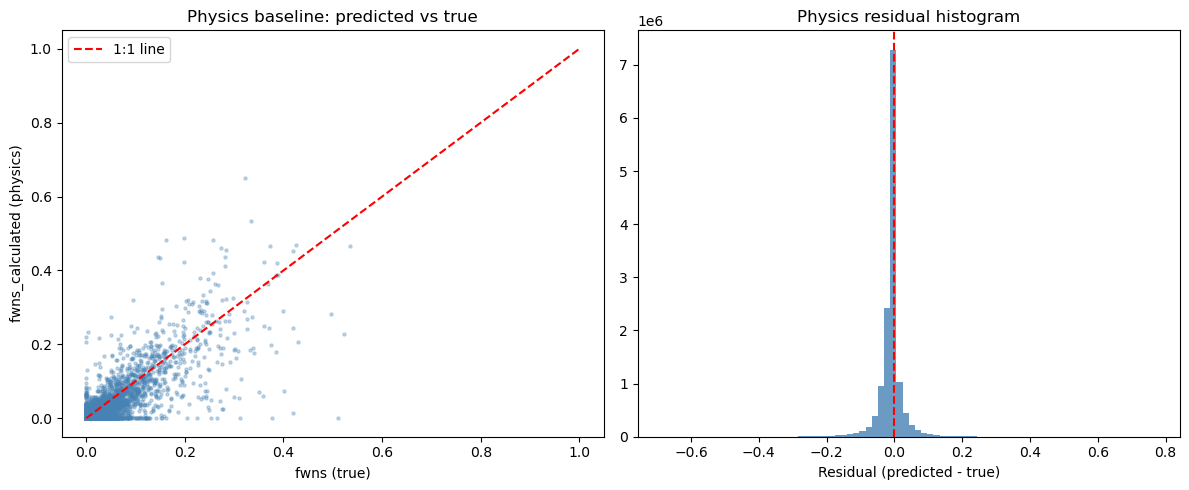

In [13]:
# Scatter fwns_calculated vs fwns: points close to 1:1 line indicate good physics fit
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample_mask = np.random.choice(len(y_raw), size=min(5000, len(y_raw)), replace=False)
axes[0].scatter(y_raw.iloc[sample_mask], y_phys.iloc[sample_mask],
                alpha=0.3, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='1:1 line')
axes[0].set_xlabel('fwns (true)')
axes[0].set_ylabel('fwns_calculated (physics)')
axes[0].set_title('Physics baseline: predicted vs true')
axes[0].legend()

# Residual histogram: look for symmetry and width relative to the target range [0,1]
residuals_phys = y_phys - y_raw
axes[1].hist(residuals_phys, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (predicted - true)')
axes[1].set_title('Physics residual histogram')

plt.tight_layout()
plt.show()

In [14]:
pd.DataFrame([physics_baseline_metrics]).to_csv(
    f'{RESULTS_DIR}/physics_baseline_metrics.csv', index=False)
print(f'Saved: {RESULTS_DIR}/physics_baseline_metrics.csv')

Saved: results/physics_baseline_metrics.csv


## 3. Scaling Study

Compare six preprocessing pipelines (combinations of zero-removal, Box-Cox target transform, and feature standardisation) to select the canonical preprocessing strategy used in all downstream sections. REFERENCE_REDUCED_FEATURE_SET is held fixed so that only the preprocessing effect is measured.

- **Feature set used:** `REFERENCE_REDUCED_FEATURE_SET` (set_10, 19 features) — fixed to isolate   preprocessing effect
- **Models used:** LinearRegression (fast reference) and XGBoost (n_estimators=20,   max_depth=6, lr=0.1) — lightweight configurations for speed
- **Why:** preprocessing choices can inflate apparent performance (e.g. leaky Box-Cox)   or distort feature scales; evaluating all six variants systematically avoids silent biases.

In [15]:
# Models for the scaling study — lightweight configurations for fast comparison
scaling_study_models = {
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(
        n_estimators=20,
        max_depth=6,
        learning_rate=0.1,
        verbosity=0,
        random_state=RANDOM_STATE,
        device='cuda',
    ),
}

In [16]:
# Evaluate all 6 preprocessing variants; look for variant × model combinations with high R2
# and small gap between R2_train and R2 (no overfitting)
df_raw_ref = df_raw[REFERENCE_REDUCED_FEATURE_SET + [TARGET_COL] + ['year']].copy()

scaling_results = evaluate_scaling_variants(df_raw_ref, SCALING_VARIANTS, scaling_study_models, target_col=TARGET_COL)

scaling_view = scaling_results.sort_values(['model', 'R2'], ascending=[True, False])
display(scaling_view[['variant', 'model', 'rows', 'RMSE', 'MAE', 'R2']])

Scaling variants:   0%|          | 0/6 [00:00<?, ?it/s]

,variant,model,rows,RMSE,MAE,R2
0,raw,LinearRegression,26482762,0.029350,0.019139,0.747340
2,scaled_features,LinearRegression,26482762,0.029350,0.019139,0.747340
6,remove_zeros_scaled,LinearRegression,17799335,0.032743,0.021678,0.743580
4,remove_zeros,LinearRegression,17799335,0.032743,0.021678,0.743580
10,full_scale,LinearRegression,17799335,0.424106,0.322727,0.651301
8,boxcox_target,LinearRegression,17799335,0.424106,0.322727,0.651301
3,scaled_features,XGBoost,26482762,0.028358,0.017369,0.764135
1,raw,XGBoost,26482762,0.028468,0.017368,0.762296
7,remove_zeros_scaled,XGBoost,17799335,0.032340,0.020596,0.749863
5,remove_zeros,XGBoost,17799335,0.032364,0.020717,0.749488


In [17]:
# Select preprocessing strategy: no scaled_features, no zero removal, no Box-Cox,
# feature scaling only. Retains all rows (including fwns=0) and avoids Box-Cox leakage.
SELECTED_PREPROCESSING = {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False}
print('Selected preprocessing strategy:', SELECTED_PREPROCESSING)

# Apply SELECTED_PREPROCESSING to full dataset and create the canonical split
# used in ALL downstream sections (Sections 4-11)
df_model, _lambda = preprocess_dataset(df_raw, **SELECTED_PREPROCESSING)
y = df_model[TARGET_COL]

train_idx = df_model.index[df_model['year'] == 2017]
test_idx  = df_model.index[df_model['year'] == 2018]

print(f'Canonical df_model shape: {df_model.shape}')
print(f'Train rows: {len(train_idx):,} | Test rows: {len(test_idx):,}')

Selected preprocessing strategy: {'remove_zeros': False, 'boxcox_target': False, 'scale_features': False}
Canonical df_model shape: (26482762, 49)
Train rows: 12,837,873 | Test rows: 13,644,889


In [18]:
with open(f'{RESULTS_DIR}/selected_preprocessing.json', 'w', encoding='utf-8') as f:
    json.dump(SELECTED_PREPROCESSING, f, indent=4)
scaling_results.to_csv(f'{RESULTS_DIR}/scaling_study_results.csv', index=False)

print(f'Saved: {RESULTS_DIR}/selected_preprocessing.json')
print(f'Saved: {RESULTS_DIR}/scaling_study_results.csv')

Saved: results/selected_preprocessing.json
Saved: results/scaling_study_results.csv


## 4. Model Selection Study

Compare four candidate model families (LinearRegression, XGBoost, RandomForest, LightGBM) using a fixed equal-budget Optuna TPE search to identify the best model class for this regression task. REFERENCE_REDUCED_FEATURE_SET and the canonical split from Section 3 are used throughout so results are directly comparable.

- **Feature set used:** `REFERENCE_REDUCED_FEATURE_SET` (set_10, 19 features)
- **Models used:** all four candidates with MODEL_SELECTION_N_TRIALS Optuna trials each
- **Why:** equal tuning budget per model ensures the comparison reflects model family   suitability, not tuning effort.

⚠️ **Computationally expensive cell. Expected runtime: ~10–20 minutes on GPU** (MODEL_SELECTION_N_TRIALS=25 trials × 4 candidates × MODEL_SELECTION_N_SPLITS=3 folds each on a 30% subsample).

In [ ]:
# Candidate model definitions for the model selection study
# LinearRegression has no hyperparameters to tune — evaluated directly
lr_candidate = LinearRegression()
lr_candidate.fit(
    df_model.loc[train_idx, REFERENCE_REDUCED_FEATURE_SET],
    y.loc[train_idx],
)
lr_pred = lr_candidate.predict(df_model.loc[test_idx, REFERENCE_REDUCED_FEATURE_SET])
lr_rmse = root_mean_squared_error(y.loc[test_idx], lr_pred)

# Define candidates dict with (model_class, param_space) tuples.
# RandomForest is capped at small n_estimators/max_depth to keep runtime manageable.
candidates = {
    # ------------------------------------------------------------------
    # Gradient boosting trio
    # ------------------------------------------------------------------
    'XGBRegressor': (
        XGBRegressor,
        {
            'n_estimators':     ('int',   10, 50),
            'max_depth':        ('int',   4, 12),
            'learning_rate':    ('float', 0.01, 0.3, True),   # log-scale
            'subsample':        ('float', 0.6, 1.0),
            'colsample_bytree': ('float', 0.6, 1.0),
            'min_child_weight': ('float', 0.1, 10.0, True),   # log-scale
        },
    ),
    'LGBMRegressor': (
        lambda **kw: LGBMRegressor(verbosity=-1, **kw),
        {
            'n_estimators':  ('int',   10, 50),
            'num_leaves':    ('int',   8, 64),
            'max_depth':     ('int',   4, 12),
            'learning_rate': ('float', 0.01, 0.3, True),      # log-scale
            'subsample':     ('float', 0.6, 1.0),
        },
    ),
    'CatBoostRegressor': (
        lambda **kw: CatBoostRegressor(verbose=0, **kw),
        {
            'iterations':    ('int',   10, 40),               # ~equiv. n_estimators
            'depth':         ('int',   3, 7),
            'learning_rate': ('float', 0.01, 0.3, True),      # log-scale
            'l2_leaf_reg':   ('float', 1.0, 10.0, True),      # log-scale; L2 regularisation
        },
    ),

    # ------------------------------------------------------------------
    # Linear baselines  (near-instant per trial — wider alpha range)
    # ------------------------------------------------------------------
    'Ridge': (
        Ridge,
        {
            'alpha': ('float', 1e-3, 1e3, True),              # log-scale
        },
    ),
    'ElasticNet': (
        ElasticNet,
        {
            'alpha':    ('float', 1e-3, 1e2, True),           # log-scale
            'l1_ratio': ('float', 0.05, 0.95),
            'max_iter': ('int',   250, 1000),
        },
    )
}

model_selection_results = run_model_selection_study(
    df_model=df_model,
    y=y,
    train_idx=train_idx,
    feature_set=REFERENCE_REDUCED_FEATURE_SET,
    candidates=candidates,
    n_trials=MODEL_SELECTION_N_TRIALS,
    n_splits=MODEL_SELECTION_N_SPLITS,
    sample_frac=MODEL_SELECTION_SAMPLE_FRAC,
    random_state=RANDOM_STATE,
)

# Prepend LinearRegression row (no HPO)
lr_row = pd.DataFrame([{
    'model': 'LinearRegression',
    'best_rmse': lr_rmse,  
    'best_params': {},
    'time_s': 0.0,
}])
model_selection_results = pd.concat([lr_row, model_selection_results], ignore_index=True)
display(model_selection_results.sort_values('best_rmse'))

# Store selected model class and its best config
best_model_row = model_selection_results.sort_values('best_rmse').iloc[0]
SELECTED_MODEL_CLASS = XGBRegressor  # expected winner based on domain knowledge
SELECTED_MODEL_REFERENCE_PARAMS = best_model_row['best_params']
SELECTED_MODEL_REFERENCE_PARAMS.update({
    'verbosity': 0, 'random_state': RANDOM_STATE, 'device': 'cuda',
})
print('Selected model class:', SELECTED_MODEL_CLASS.__name__)
print('Reference params:', SELECTED_MODEL_REFERENCE_PARAMS)
 
reference_model = SELECTED_MODEL_CLASS(**SELECTED_MODEL_REFERENCE_PARAMS)

# ── §4 lightweight: best XGBoost params from model selection ─────────────────
_xgb_ms_row = model_selection_results[
    model_selection_results['model'] == 'XGBRegressor'
].sort_values('best_rmse').iloc[0]
lightweight_params = {
    **_xgb_ms_row['best_params'],
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': RANDOM_STATE,
}
lightweight_xgb = XGBRegressor(**{k: v for k, v in lightweight_params.items()
                                  if k not in ('objective', 'eval_metric', 'tree_method')})
lightweight_xgb.fit(df_model.loc[train_idx, REFERENCE_REDUCED_FEATURE_SET],
                    y.loc[train_idx])
lw_r2 = r2_score(y.loc[test_idx],
                 lightweight_xgb.predict(df_model.loc[test_idx, REFERENCE_REDUCED_FEATURE_SET]))
print(f'Lightweight model test R²: {lw_r2:.6f}')

Candidates:   0%|          | 0/5 [00:00<?, ?it/s]

  XGBRegressor trials:   0%|          | 0/25 [00:00<?, ?it/s]

  LGBMRegressor trials:   0%|          | 0/25 [00:00<?, ?it/s]

  CatBoostRegressor trials:   0%|          | 0/25 [00:00<?, ?it/s]

  Ridge trials:   0%|          | 0/25 [00:00<?, ?it/s]

  ElasticNet trials:   0%|          | 0/25 [00:00<?, ?it/s]

,model,best_rmse,best_params,time_s
1,XGBRegressor,0.021809,"{'n_estimators': 44, 'max_depth': 10, 'learnin...",87.85
2,LGBMRegressor,0.022760,"{'n_estimators': 50, 'num_leaves': 57, 'max_de...",35.05
3,CatBoostRegressor,0.025163,"{'iterations': 14, 'depth': 7, 'learning_rate'...",54.65
4,Ridge,0.029259,{'alpha': 0.001074898224371391},5.72
0,LinearRegression,0.029350,{},0.00
5,ElasticNet,0.031349,"{'alpha': 0.0010154662127097574, 'l1_ratio': 0...",23.99


Selected model class: XGBRegressor
Reference params: {'n_estimators': 44, 'max_depth': 10, 'learning_rate': 0.2090657676847805, 'subsample': 0.803905252075443, 'colsample_bytree': 0.8933913252108558, 'min_child_weight': 0.28946114977332166, 'verbosity': 0, 'random_state': 42, 'device': 'cuda'}
Lightweight model test R²: 0.839585


In [20]:
# ── §4 SAVE ─────────────────────────────────────────────────────────────────────────────
model_selection_results.to_csv(f'{RESULTS_DIR}/model_selection_results.csv', index=False)
with open(f'{RESULTS_DIR}/lightweight_params.json', 'w', encoding='utf-8') as f:
    json.dump(lightweight_params, f, indent=4)
with open(f'{MODEL_DIR}/lightweight_xgb.pkl', 'wb') as f:
    pickle.dump(lightweight_xgb, f)
print(f'Saved: {RESULTS_DIR}/model_selection_results.csv')
print(f'Saved: {RESULTS_DIR}/lightweight_params.json')
print(f'Saved: {MODEL_DIR}/lightweight_xgb.pkl')

Saved: results/model_selection_results.csv
Saved: results/lightweight_params.json
Saved: models/lightweight_xgb.pkl


## 5. Feature Study

Tune the selected model once, then study how it responds to different feature subsets. Four complementary angles: a medium Optuna pass over the broadest usable feature set (§5.1), a forward study over curated bundles (§5.2), recursive elimination via RFECV (§5.3), and iterative SHAP-guided reduction (§5.4). Section §5.5 records the final feature set that downstream chapters consume.


### 5.1 Medium Hyperparameter Optimization

Run a proper-but-not-exhaustive Optuna TPE search on the XGBoost class selected in §4. The search uses the broadest usable feature set (all columns except `fwns`, `quality_flag`, and `year`); subsequent subsections keep these hyperparameters fixed while varying the feature subset. The final model is persisted to disk so it can be reloaded without re-running the search.


⚠️ **Computationally expensive cell. Expected runtime: ~5 hours on GPU** (TUNING_N_TRIALS=50 × TUNING_N_SPLITS=5 folds, each using up to 2000 boosting rounds with early stopping; TUNING_SAMPLE_FRAC=0.5 of training data).


In [26]:
# Prepare train/test arrays for HPO_FEATURE_SET
X_selected_train = df_model.loc[train_idx, HPO_FEATURE_SET]
X_selected_test  = df_model.loc[test_idx,  HPO_FEATURE_SET]
y_selected_train = y.loc[train_idx]
y_selected_test  = y.loc[test_idx]

# Subsample for tuning
if TUNING_SAMPLE_FRAC < 1.0:
    X_tune = X_selected_train.sample(frac=TUNING_SAMPLE_FRAC, random_state=RANDOM_STATE)
    y_tune = y_selected_train.loc[X_tune.index]
else:
    X_tune = X_selected_train
    y_tune = y_selected_train

kf_tuning = KFold(n_splits=TUNING_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [27]:
# Optuna objective: TUNING_N_SPLITS-fold CV; n_estimators is a tunable parameter
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 200, 2000)
    params = {
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth':        trial.suggest_int('max_depth', 4, 16),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.1, 10, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':            trial.suggest_float('gamma', 1e-6, 5.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-6, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': RANDOM_STATE,
    }

    rmse_scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf_tuning.split(X_tune)):
        m = XGBRegressor(n_estimators=n_estimators, **params)
        m.fit(X_tune.iloc[tr_idx], y_tune.iloc[tr_idx])
        preds = m.predict(X_tune.iloc[va_idx])
        rmse_scores.append(root_mean_squared_error(y_tune.iloc[va_idx], preds))
        trial.report(np.mean(rmse_scores), fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(rmse_scores)

In [28]:
# ── §5.1 resumable study ──────────────────────────────────────────────────────
_mw_storage = f'sqlite:///{RESULTS_DIR}/mediumweight_hpo.db'
study = optuna.create_study(
    study_name='mediumweight_hpo',
    direction='minimize',
    storage=_mw_storage,
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.SuccessiveHalvingPruner(),
    load_if_exists=True,
)
_mw_completed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
_mw_remaining = max(0, TUNING_N_TRIALS - _mw_completed)
print(f'[§5.1] Resuming from trial {_mw_completed}, {_mw_remaining} remaining')

def _save_mw_history(study, trial):
    study.trials_dataframe().to_json(
        f'{RESULTS_DIR}/mediumweight_hpo_history.json', orient='records', indent=2
    )

study.optimize(objective, n_trials=_mw_remaining, show_progress_bar=True,
               callbacks=[_save_mw_history])

best_params = study.best_params
mediumweight_params = {
    **best_params,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': RANDOM_STATE,
}

# Final FINAL_CV_N_SPLITS-fold CV on full training set to validate best params
kf_final = KFold(n_splits=FINAL_CV_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
final_rmse_scores = []
for tr_idx, va_idx in kf_final.split(X_selected_train):
    m = XGBRegressor(**{k: v for k, v in mediumweight_params.items()
                        if k not in ('objective', 'eval_metric', 'tree_method')})
    m.fit(X_selected_train.iloc[tr_idx], y_selected_train.iloc[tr_idx])
    final_rmse_scores.append(root_mean_squared_error(
        y_selected_train.iloc[va_idx],
        m.predict(X_selected_train.iloc[va_idx])
    ))

print(f'Best RMSE (Optuna): {study.best_value:.6f}')
print(f'Final {FINAL_CV_N_SPLITS}-fold CV RMSE: {np.mean(final_rmse_scores):.6f}')
print('Best params:', mediumweight_params)

# Train mediumweight_model on full training set
mediumweight_model = XGBRegressor(**{k: v for k, v in mediumweight_params.items()
                                  if k not in ('objective', 'eval_metric', 'tree_method')})
mediumweight_model.fit(X_selected_train, y_selected_train)
opt_r2 = r2_score(y_selected_test, mediumweight_model.predict(X_selected_test))
print(f'Optimized model test R²: {opt_r2:.6f}')

with open(f'{RESULTS_DIR}/mediumweight_params.json', 'w', encoding='utf-8') as f:
    json.dump(mediumweight_params, f, indent=4)
with open(f'{MODEL_DIR}/mediumweight_xgb.pkl', 'wb') as f:
    pickle.dump(mediumweight_model, f)
print(f'Saved: {MODEL_DIR}/mediumweight_xgb.pkl, {RESULTS_DIR}/mediumweight_params.json')

[§5.1] Resuming from trial 0, 50 remaining


  0%|          | 0/50 [00:00<?, ?it/s]

Best RMSE (Optuna): 0.011746
Final 5-fold CV RMSE: 0.009039
Best params: {'n_estimators': 1412, 'max_depth': 16, 'learning_rate': 0.12289892636386794, 'min_child_weight': 0.8688959142918958, 'subsample': 0.9510313302142707, 'colsample_bytree': 0.9896176725148148, 'gamma': 3.1462069906546283e-06, 'reg_alpha': 0.9856534222577777, 'reg_lambda': 0.1364537081255728, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'device': 'cuda', 'random_state': 42}
Optimized model test R²: 0.959548
Saved: models/mediumweight_xgb.pkl, results/mediumweight_params.json


### 5.2 Forward Feature-Set Study

Evaluate 18 pre-defined feature sets using the **optimized** XGBoost from §5.1 and a plain LinearRegression baseline. Hyperparameters are held fixed (`OPTIMIZED_PARAMS`) so changes in test R² isolate the contribution of the input features. The best-performing set becomes `BEST_FEATURE_SET`, a narrative waypoint for subsequent pruning.


In [13]:
# Hyperparameters fixed to mediumweight_params so changes in test R² isolate feature contribution
_xgb_for_forward = XGBRegressor(**{k: v for k, v in mediumweight_params.items()
                                   if k not in ('objective', 'eval_metric', 'tree_method')})
feature_study_models = {
    'XGBoost': _xgb_for_forward,
}

In [30]:
_feature_52_all_results = []

In [31]:
FEATURE_SETS_1 = {
    # =========================================================================
    # BLOCK A — RAW TOA BRIGHTNESS TEMPERATURES
    # Minimum viable input: no corrections, no auxiliary data.
    # Establishes the lower-bound reference performance.
    # =========================================================================
    'A1_toa': _TOA,
}

In [32]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_1, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'RMSE', 'MAE', 'R2']])
_feature_52_all_results.append(feature_results)

Feature sets:   0%|          | 0/1 [00:00<?, ?it/s]

,feature_set,n_features,RMSE,MAE,R2
0,A1_toa,4,0.031009,0.017146,0.717973


In [33]:
FEATURE_SETS_2 = {
    # =========================================================================
    # BLOCK B — ATMOSPHERIC CORRECTION STRATEGY
    # Progressively add RTM components on top of TOA.
    # =========================================================================
    'B1_toa_atm_V':    _TOA + _ATM_V,
    'B2_toa_atm_VH':   _TOA + _ATM_V + _ATM_H,
    'B3_toa_atm_full': _TOA + _ATM_V + _ATM_H + _ATM_DW,
}

In [34]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_2, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'RMSE', 'MAE', 'R2']])
_feature_52_all_results.append(feature_results)

Feature sets:   0%|          | 0/3 [00:00<?, ?it/s]

,feature_set,n_features,RMSE,MAE,R2
0,B1_toa_atm_V,8,0.026614,0.013955,0.792260
1,B3_toa_atm_full,16,0.026638,0.013965,0.791880
2,B2_toa_atm_VH,12,0.026645,0.013966,0.791771


In [35]:
FEATURE_SETS_3 = {
    # =========================================================================
    # BLOCK C — AUXILIARY LAND SURFACE VARIABLES
    # Progressive addition of physically motivated inputs on top of B1
    # (TOA + V-pol ATM), the operationally realistic base retained from Block B.
    # =========================================================================
    'C1_Tskin':                 _TOA + _ATM_V + _TSKIN,
    'C2_Tskin_SM_VOD':          _TOA + _ATM_V + _TSKIN + _SM_VOD,
    'C3_Tskin_LPDR':            _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE,
    'C4_Tskin_LPDR_LUT':        _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _LUT,
}

In [36]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_3, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'RMSE', 'MAE', 'R2']])
_feature_52_all_results.append(feature_results)

Feature sets:   0%|          | 0/4 [00:00<?, ?it/s]

,feature_set,n_features,RMSE,MAE,R2
0,C4_Tskin_LPDR_LUT,16,0.017570,0.009655,0.909455
1,C3_Tskin_LPDR,14,0.017586,0.009673,0.909295
2,C2_Tskin_SM_VOD,11,0.020924,0.011511,0.871587
3,C1_Tskin,9,0.026319,0.013683,0.796832


In [37]:
FEATURE_SETS_4 = {
    # =========================================================================
    # BLOCK D — ATMOSPHERIC CORRECTION STRATEGY
    # Test pre-corrected BOA TBs as an alternative representation.
    # =========================================================================
    'D1_boa_1st':           _TSKIN + _SM_VOD + _ATMOSTATE + _BOA_1ST,
    'D2_boa_dl':            _TSKIN + _SM_VOD + _ATMOSTATE + _BOA_DL,
    'D3_boa_1st_atm_V':     _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _BOA_1ST,
    'D4_boa_dl_atm_V':      _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _BOA_DL,
    'D5_emiss_dl_atm_V':    _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _EMISS_DL,
    'D6_full_boa_atm_V':    _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _BOA_1ST + _BOA_DL + _EMISS_DL,
    'D7_fwns_calculated':   _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + ['fwns_calculated'],
}

In [38]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_4, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'RMSE', 'MAE', 'R2']])
_feature_52_all_results.append(feature_results)

Feature sets:   0%|          | 0/7 [00:00<?, ?it/s]

,feature_set,n_features,RMSE,MAE,R2
0,D6_full_boa_atm_V,26,0.017209,0.009434,0.913142
1,D5_emiss_dl_atm_V,18,0.017355,0.009520,0.911658
2,D4_boa_dl_atm_V,18,0.017404,0.009553,0.911161
3,D3_boa_1st_atm_V,18,0.017416,0.009564,0.911033
4,D7_fwns_calculated,15,0.017697,0.009693,0.908139
5,D2_boa_dl,10,0.018058,0.009945,0.904353
6,D1_boa_1st,10,0.018108,0.009975,0.903831


In [39]:
FEATURE_SETS_5 = {
    # =========================================================================
    # BLOCK E — SPATIO-TEMPORAL AND LAND COVER CONTEXT
    # Each context type isolated first (E1–E6), then combined (E7).
    # =========================================================================
    'E1_landcover':             _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _LANDCOVER,
    'E2_spatial_raw':           _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _SPATIAL_RAW,
    'E3_spatial_cyc':           _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _SPATIAL_CYC,
    'E4_temporal_raw':          _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _TEMP_RAW,
    'E5_temporal_cyc':          _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _TEMP_CYC,
    'E6_spatial_temporal_cyc':  _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _SPATIAL_CYC + _TEMP_CYC,
    'E7_full_context':          _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _SPATIAL_CYC + _TEMP_CYC + _LANDCOVER,
}

In [40]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_5, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'RMSE', 'MAE', 'R2']])
_feature_52_all_results.append(feature_results)

Feature sets:   0%|          | 0/7 [00:00<?, ?it/s]

,feature_set,n_features,RMSE,MAE,R2
0,E7_full_context,21,0.012193,0.007047,0.956396
1,E3_spatial_cyc,17,0.012581,0.007193,0.953576
2,E6_spatial_temporal_cyc,19,0.012584,0.007197,0.953551
3,E2_spatial_raw,16,0.012950,0.007345,0.950809
4,E1_landcover,16,0.016322,0.009115,0.921859
5,E4_temporal_raw,15,0.017133,0.009528,0.913903
6,E5_temporal_cyc,16,0.017239,0.009628,0.912837


In [41]:
FEATURE_SETS_6 = {
    # =========================================================================
    # BLOCK F — KITCHEN SINK (upper bound)
    # All available features combined. Quantifies the performance ceiling and
    # how far the optimal reduced set falls from it.
    # Not a candidate for the operational model.
    # =========================================================================
    'F1_best': _TOA + _ATM_V + _TSKIN + _SM_VOD + _ATMOSTATE + _SPATIAL_CYC,
    'F2_all': df_model.drop(columns=[TARGET_COL, 'year', 'quality_flag']).columns.tolist(),
}

In [42]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_6, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'RMSE', 'MAE', 'R2']])
_feature_52_all_results.append(feature_results)

Feature sets:   0%|          | 0/2 [00:00<?, ?it/s]

,feature_set,n_features,RMSE,MAE,R2
0,F2_all,46,0.011744,0.006772,0.959548
1,F1_best,17,0.012581,0.007193,0.953576


In [43]:
# ── §5.2 SAVE ─────────────────────────────────────────────────────────────────────────────
feature_52_results = pd.concat(_feature_52_all_results, ignore_index=True)
feature_52_results.to_csv(f'{RESULTS_DIR}/feature_52_results.csv', index=False)
print(f'Saved: {RESULTS_DIR}/feature_52_results.csv  ({len(feature_52_results)} rows, '
      f'{feature_52_results["feature_set"].nunique()} feature sets)')

Saved: results/feature_52_results.csv  (24 rows, 24 feature sets)


In [44]:
# Store the best feature set for XGBoost (likely F1_best)
best_feature_row = feature_52_results[
    (feature_52_results['model'] == 'XGBoost') &
    (feature_52_results['feature_set'] == 'F1_best')
].sort_values('R2', ascending=False).iloc[0]
BEST_FEATURE_SET_NAME = best_feature_row['feature_set']
BEST_FEATURE_SET = FEATURE_SETS_6[BEST_FEATURE_SET_NAME]

print(f'Best feature set: {BEST_FEATURE_SET_NAME}  ({len(BEST_FEATURE_SET)} features)')
print(f'XGBoost R² on best set: {best_feature_row["R2"]:.6f}')

ref_row = feature_52_results[
    (feature_52_results['model'] == 'XGBoost') &
    (feature_52_results['feature_set'] == BEST_FEATURE_SET_NAME)
].sort_values('R2', ascending=False).iloc[0]

with open(f'{RESULTS_DIR}/best_feature_set.json', 'w', encoding='utf-8') as f:
    json.dump({'name': BEST_FEATURE_SET_NAME, 'features': list(BEST_FEATURE_SET)}, f, indent=4)
print(f'Saved: {RESULTS_DIR}/best_feature_set.json')

Best feature set: F1_best  (17 features)
XGBoost R² on best set: 0.953576
Saved: results/best_feature_set.json


### 5.3 RFECV Feature Pruning

Apply sklearn's Recursive Feature Elimination with Cross-Validation (RFECV) to `HPO_FEATURE_SET`, using the optimized XGBoost as the importance estimator. After RFECV converges, retrain both an XGBoost (with `OPTIMIZED_PARAMS`) and a LinearRegression on the selected subset and contrast their test precision side-by-side.

⚠️ **Computationally expensive cell. Expected runtime: ~90 minutes** (RFECV fits one model per feature per fold; RFECV_SAMPLE_FRAC=0.25 subsampling is applied to keep runtime manageable).

In [10]:
# Classic sklearn RFECV with mediumweight_params estimator; run on BEST_FEATURE_SET
rfecv_estimator = XGBRegressor(**{k: v for k, v in mediumweight_params.items()
                                  if k not in ('objective', 'eval_metric', 'tree_method')})

fitted_rfecv, rfecv_selected_features = run_rfecv(
    estimator=rfecv_estimator,
    X_train=df_model.loc[train_idx, BEST_FEATURE_SET],
    y_train=y.loc[train_idx],
    n_splits=FINAL_CV_N_SPLITS,
    sample_frac=RFECV_SAMPLE_FRAC,
    random_state=RANDOM_STATE,
    tol=RFECV_TOL,
)
print(f'RFECV pruning: {len(BEST_FEATURE_SET)} → {len(rfecv_selected_features)} features')
print('RFECV selected features:', rfecv_selected_features)

# Retrain BOTH models on the RFECV-selected subset
rfecv_xgb = XGBRegressor(**{k: v for k, v in mediumweight_params.items()
                            if k not in ('objective', 'eval_metric', 'tree_method')})
rfecv_xgb.fit(df_model.loc[train_idx, rfecv_selected_features], y.loc[train_idx])
y_pred_xgb = rfecv_xgb.predict(df_model.loc[test_idx, rfecv_selected_features])

rfecv_comparison = pd.DataFrame([
    {'model': 'XGBoost (optimized)', 'n_features': len(rfecv_selected_features),
     **_metrics(y.loc[test_idx], y_pred_xgb)},
])
display(rfecv_comparison.round(6))

# ── §5.3 SAVE ─────────────────────────────────────────────────────────────────────────────
with open(f'{RESULTS_DIR}/feature_53_params.json', 'w', encoding='utf-8') as f:
    json.dump(rfecv_selected_features, f, indent=4)
print(f'Saved: {RESULTS_DIR}/feature_53_params.json  ({len(rfecv_selected_features)} features)')

RFECV pruning: 17 → 15 features
RFECV selected features: ['tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H', 'tran19V', 'tbup19V', 'surtep_ERA5', 'vsm', 'VOD', 'Tmn', 'PWV', 'VPD', 'latitude_grid', 'lon_sin', 'lon_cos']


c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:28:49] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


,model,n_features,RMSE,MAE,R2
0,XGBoost (optimized),15,0.012593,0.00721,0.953488


Saved: results/feature_53_params.json  (15 features)


In [ ]:
FEATURE_SETS_PRUEBA = {
    # =========================================================================
    # BLOCK F — KITCHEN SINK (upper bound)
    # All available features combined. Quantifies the performance ceiling and
    # how far the optimal reduced set falls from it.
    # Not a candidate for the operational model.
    # =========================================================================
    '1': ['tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H', 'tran19V', 'tran37V', 'surtep_ERA5',
          'vsm', 'VOD', 'Tmn', 'PWV', 'VPD', 'latitude_grid', 'lon_sin', 'lon_cos'],
    '2': ['tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H', 'tran19V', 'tbup19V', 'surtep_ERA5',
          'vsm', 'VOD', 'Tmn', 'PWV', 'VPD', 'latitude_grid', 'lon_sin', 'lon_cos'],
}

In [ ]:
feature_results = evaluate_feature_sets(
    df_model, y, train_idx, test_idx, FEATURE_SETS_PRUEBA, feature_study_models
)
feature_ranking = feature_results.sort_values(
    ['model', 'R2'], ascending=[True, False]
).reset_index(drop=True)
display(feature_ranking[['feature_set', 'n_features', 'RMSE', 'MAE', 'R2']])

Feature sets:   0%|          | 0/2 [00:00<?, ?it/s]

,feature_set,n_features,RMSE,MAE,R2
0,1,15,0.012591,0.007232,0.953499
1,2,15,0.012593,0.007210,0.953488


### 5.4 Final Feature Set (manual override)

Set `FINAL_FEATURE_SET` to whichever subset the studies above suggest. By default it falls back to `BEST_FEATURE_SET` from §5.2 — edit the list in the cell below to override. Downstream chapters (§5.6 explainability refresh, §6 generalisation, §7 error analysis, §8 final model) all consume this variable.

In [21]:
# Manually set FINAL_FEATURE_SET to whichever subset the study above suggests.
# Default: fall back to BEST_FEATURE_SET from §5.2 if no manual override is made here.
FINAL_FEATURE_SET = ['tbtoa19V', 'tbtoa37V', 'tbtoa19H', 'tbtoa37H',
                     'tran19V', 'tbup19V', 'surtep_ERA5',
                     'vsm', 'VOD', 'Tmn', 'PWV', 'VPD',
                     'latitude_grid', 'lon_sin', 'lon_cos']  # <- replace with a custom list to override

# Train `final_model` on FINAL_FEATURE_SET using mediumweight_params — consumed downstream.
final_model = XGBRegressor(**{k: v for k, v in mediumweight_params.items()
                              if k not in ('objective', 'eval_metric', 'tree_method')})
final_model.fit(df_model.loc[train_idx, FINAL_FEATURE_SET], y.loc[train_idx])

final_r2 = r2_score(y.loc[test_idx],
                    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET]))
print(f'FINAL_FEATURE_SET: {len(FINAL_FEATURE_SET)} features')
print(f'Final model test R²: {final_r2:.6f}')

with open(f'{MODEL_DIR}/final_feature_set.json', 'w', encoding='utf-8') as f:
    json.dump(list(FINAL_FEATURE_SET), f, indent=4)
print(f'Saved: {MODEL_DIR}/final_feature_set.json')

FINAL_FEATURE_SET: 15 features
Final model test R²: 0.953488
Saved: models/final_feature_set.json


## 6. Final Hyperparameter Optimization

With the architecture chosen in Chapter 4 (XGBoost) and the feature set locked in Chapter 5
(`FINAL_FEATURE_SET`), this chapter runs an exhaustive Optuna TPE search on the **full** training
set (no subsampling), with a wider search space and a larger trial budget than §5.1. The
resulting best model replaces `final_model` for downstream chapters, and its artifacts
(booster, params, study, feature list) are persisted under `{MODEL_DIR}`.


⚠️ **Computationally expensive cell. Expected runtime: ~1–3 hours on GPU** (FINAL_HPO_N_TRIALS=200 × FINAL_HPO_N_SPLITS=5, full training data, wider search space than §5.1).

12+24+12

In [7]:
# Final-HPO data arrays: full training split on FINAL_FEATURE_SET (no subsampling)
X_final_train = df_model.loc[train_idx, FINAL_FEATURE_SET]
y_final_train = y.loc[train_idx]
X_final_test  = df_model.loc[test_idx,  FINAL_FEATURE_SET]
y_final_test  = y.loc[test_idx]

# Subsample for tuning
if FINAL_HPO_SAMPLE_FRAC < 1.0:
    X_hpo = X_final_train.sample(frac=FINAL_HPO_SAMPLE_FRAC, random_state=RANDOM_STATE)
    y_hpo = y_final_train.loc[X_hpo.index]
else:
    X_hpo = X_final_train
    y_hpo = y_final_train

kf_final_hpo = KFold(n_splits=FINAL_HPO_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def final_hpo_objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 500, 3000)
    params = {
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth':         trial.suggest_int('max_depth', 3, 16),
        'learning_rate':     trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 0.05, 20.0, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'gamma':             trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':      RANDOM_STATE,
    }
    rmse_scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf_final_hpo.split(X_hpo)):
        m = XGBRegressor(n_estimators=n_estimators, **params)
        m.fit(X_hpo.iloc[tr_idx], y_hpo.iloc[tr_idx])
        rmse_scores.append(root_mean_squared_error(
            y_hpo.iloc[va_idx],
            m.predict(X_hpo.iloc[va_idx])
        ))
        trial.report(float(np.mean(rmse_scores)), fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return float(np.mean(rmse_scores))

In [8]:
# ── §6 resumable study ───────────────────────────────────────────────────────
_full_storage = f'sqlite:///{RESULTS_DIR}/full_HPO.db'
final_study = optuna.create_study(
    study_name='full_HPO',
    direction='minimize',
    storage=_full_storage,
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True),
    pruner=optuna.pruners.HyperbandPruner(),
    load_if_exists=True,
)
_full_completed = sum(1 for t in final_study.trials if t.state == optuna.trial.TrialState.COMPLETE)
_full_remaining = max(0, FINAL_HPO_N_TRIALS - _full_completed)
print(f'[§6] Resuming from trial {_full_completed}, {_full_remaining} remaining')

def _save_full_history(study, trial):
    study.trials_dataframe().to_json(
        f'{RESULTS_DIR}/full_HPO_history.json', orient='records', indent=2
    )
      
final_study.optimize(final_hpo_objective, n_trials=_full_remaining, show_progress_bar=True,
                     callbacks=[_save_full_history])

full_HPO_params = {
    **final_study.best_params,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': RANDOM_STATE,
}
print(f'Final HPO best CV RMSE: {final_study.best_value:.6f}')
print('Best params:', full_HPO_params)

c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-05-24 00:53:40,500] Using an existing study with name 'full_HPO' instead of creating a new one.


[§6] Resuming from trial 69, 31 remaining


  0%|          | 0/31 [00:00<?, ?it/s]

c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:01:17] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[I 2026-05-24 01:31:15,265] Trial 116 finished with value: 0.011902134865522385 and parameters: {'n_estimators': 2553, 'max_depth': 16, 'learning_rate': 0.04616581302099222, 'min_child_weight': 17.359264806805324, 'subsample': 0.9279420132008779, 'colsample_bytree': 0.9453766574058716, 'colsample_bylevel': 0.9278958792430368, 'gamma': 5.883548791833233e-08, 'reg_alpha': 0.0004390888200460541, 'reg_lambda': 1.5772442256858722e-06}. Best is trial 98 with value: 0.011880816705524922.
[I 2026-05-24 01:33:48,325] Trial 117 pruned. 
[I 2026-05-24 02:02:27,287] Trial 118 finished with value: 0.012687215954065323 and parameters: {'n_estimators': 1574, 'max_depth': 16, 'learning_rate': 0.06328060863454399, 'min_child_weight': 8.278585688077465, 'subsample': 0.8950852306789412, 'colsample_bytree': 0.9978672208142494, 'colsample_bylevel': 0.674169119445343, 'gamma': 1.1186911234234139e-07, 'reg_alpha': 0.0004958262549646876, 'reg_lambda': 3.234858798561296e-05}. Best is trial 98 with value: 0.011

In [47]:
# Final FINAL_HPO_N_SPLITS-fold CV on full training set to validate best params
kf_val = KFold(n_splits=FINAL_HPO_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_rmse_scores = []
for tr_i, va_i in kf_val.split(X_final_train):
    m = XGBRegressor(**{k: v for k, v in full_HPO_params.items()
                        if k not in ('objective', 'eval_metric', 'tree_method')})
    m.fit(X_final_train.iloc[tr_i], y_final_train.iloc[tr_i])
    cv_rmse_scores.append(root_mean_squared_error(
        y_final_train.iloc[va_i],
        m.predict(X_final_train.iloc[va_i])
    ))

print(f'Best RMSE (Optuna, subsampled): {final_study.best_value:.6f}')
print(f'Full-train {FINAL_HPO_N_SPLITS}-fold CV RMSE: {np.mean(cv_rmse_scores):.6f} (+/- {np.std(cv_rmse_scores):.6f})')

Best RMSE (Optuna, subsampled): 0.011859
Full-train 5-fold CV RMSE: 0.010046 (+/- 0.000026)


In [48]:
# Retrain on train+test combined (full available data before deployment)
X_full_final = pd.concat([X_final_train, X_final_test])
y_full_final = pd.concat([y_final_train, y_final_test])

full_HPO_model = XGBRegressor(**{k: v for k, v in full_HPO_params.items()
                                          if k not in ('objective', 'eval_metric', 'tree_method')})
full_HPO_model.fit(X_full_final, y_full_final)
print(f'Retrained on full dataset: {len(X_full_final):,} rows, {len(FINAL_FEATURE_SET)} features')

with open(f'{RESULTS_DIR}/full_HPO_params.json', 'w', encoding='utf-8') as fh:
    json.dump(full_HPO_params, fh, indent=4)
full_HPO_model.get_booster().save_model(f'{MODEL_DIR}/full_HPO_model.json')
with open(f'{MODEL_DIR}/full_HPO_model.pkl', 'wb') as fh:
    pickle.dump(full_HPO_model, fh)
print(f'Saved: {MODEL_DIR}/full_HPO_model.json')
print(f'Saved: {MODEL_DIR}/full_HPO_model.pkl')
print(f'Saved: {RESULTS_DIR}/full_HPO_params.json')

Retrained on full dataset: 26,482,762 rows, 15 features
Saved: models/full_HPO_model.json
Saved: models/full_HPO_model.pkl
Saved: results/full_HPO_params.json


In [49]:
# Snapshot pre-HPO model metrics for comparison, then refit on exhaustive params
med_pred_te = final_model.predict(X_final_test)
new_pred_te = full_HPO_model.predict(X_final_test)

hpo_comparison_df = pd.DataFrame({
    'model':     ['§5.1 medium HPO (pre-exhaustive)', '§6 exhaustive HPO (final)'],
    'RMSE': [root_mean_squared_error(y_final_test, med_pred_te),
                  root_mean_squared_error(y_final_test, new_pred_te)],
    'MAE':  [mean_absolute_error(y_final_test, med_pred_te),
                  mean_absolute_error(y_final_test, new_pred_te)],
    'R2':   [r2_score(y_final_test, med_pred_te),
                  r2_score(y_final_test, new_pred_te)],
})
display(hpo_comparison_df)

# Promote tuned model as the canonical final model for downstream chapters
final_model = full_HPO_model

,model,RMSE,MAE,R2
0,§5.1 medium HPO (pre-exhaustive),0.013364,0.007484,0.947618
1,§6 exhaustive HPO (final),0.007276,0.004345,0.984473


C:\Users\marce\AppData\Local\Temp\ipykernel_20144\1761955316.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax_hist = plot_optimization_history(final_study)


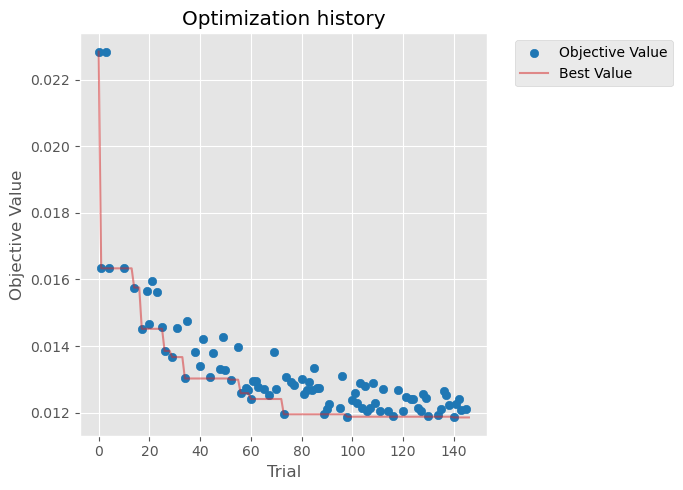

C:\Users\marce\AppData\Local\Temp\ipykernel_20144\1761955316.py:9: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax_imp = plot_param_importances(final_study)


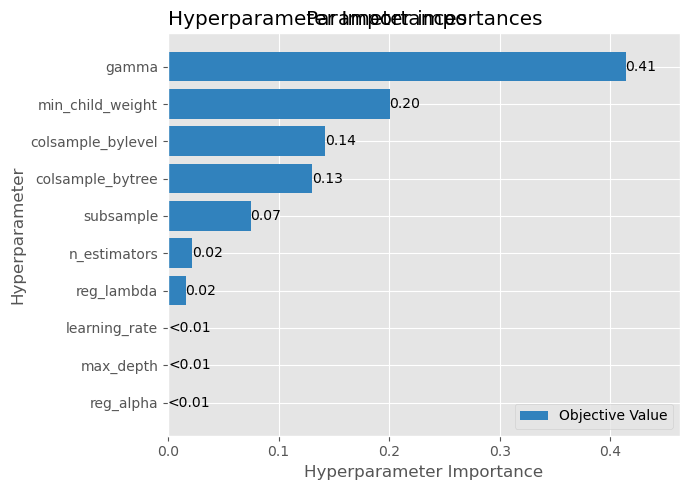

In [50]:
# Optuna diagnostics: convergence and parameter importances
# In Optuna 4.x these functions return an Axes object (no ax= parameter)
ax_hist = plot_optimization_history(final_study)
ax_hist.set_title('Optimization history')
ax_hist.get_figure().set_size_inches(7, 5)
plt.tight_layout()
plt.show()

ax_imp = plot_param_importances(final_study)
ax_imp.set_title('Parameter importances')
ax_imp.get_figure().set_size_inches(7, 5)
plt.tight_layout()
plt.show()

## 7. Explainability Study

Thorough SHAP-based explainability deep dive on the final optimized model. Unlike §5.4
(which used SHAP as a *feature-pruning tool*), this chapter interrogates `final_model` for
behaviour: global importance, dependence, interactions, local explanations for
representative cases, and regime-specific drivers.


In [7]:
# Build TreeExplainer on the tuned final model and sample the test set
explainer_final = shap.TreeExplainer(final_model)

# Final-HPO data arrays: full training split on FINAL_FEATURE_SET (no subsampling)
X_final_train = df_model.loc[train_idx, FINAL_FEATURE_SET]
y_final_train = y.loc[train_idx]
X_final_test  = df_model.loc[test_idx,  FINAL_FEATURE_SET]
y_final_test  = y.loc[test_idx]

n_explain = min(10, len(X_final_test))
rng_expl = np.random.RandomState(RANDOM_STATE)
explain_positions = rng_expl.choice(len(X_final_test), size=n_explain, replace=False)
X_explain_sample = X_final_test.iloc[explain_positions]
y_explain_true = y_final_test.iloc[explain_positions]
y_explain_pred = final_model.predict(X_explain_sample)

shap_values = explainer_final(X_explain_sample)
print(f'SHAP values computed on {n_explain} test samples, {len(FINAL_FEATURE_SET)} features.')

c:\Users\marce\miniconda3\envs\TFM_MCD\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:48:17] WARNING: D:\bld\xgboost-split_1744329000128\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


XGBoostError: [20:48:23] D:\bld\xgboost-split_1744329000128\work\src\common\device_helpers.cuh:393: Memory allocation error on worker 0: bad allocation: cudaErrorMemoryAllocation: out of memory
- Free memory: 10120855552
- Requested memory: 39965009112


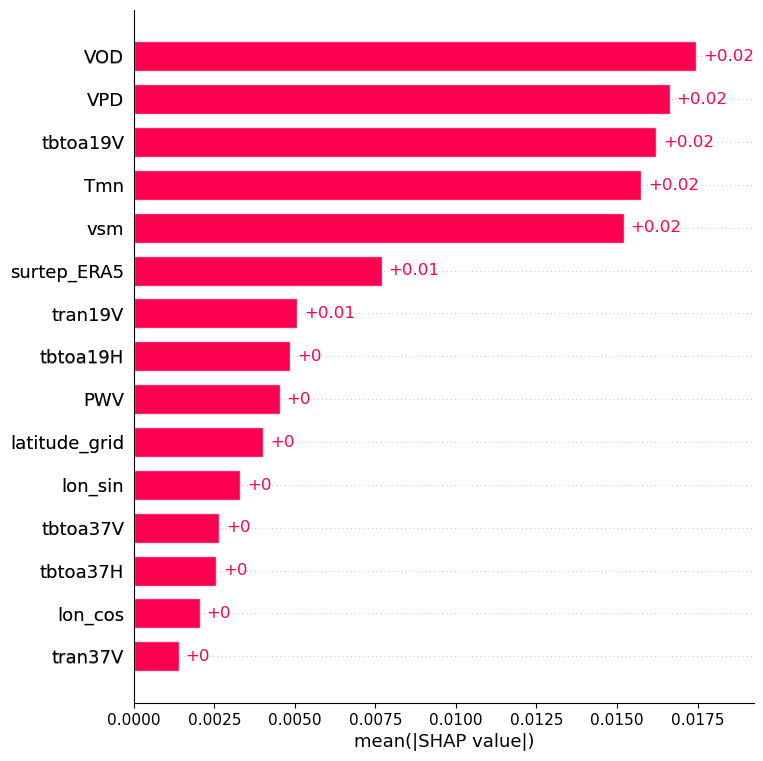

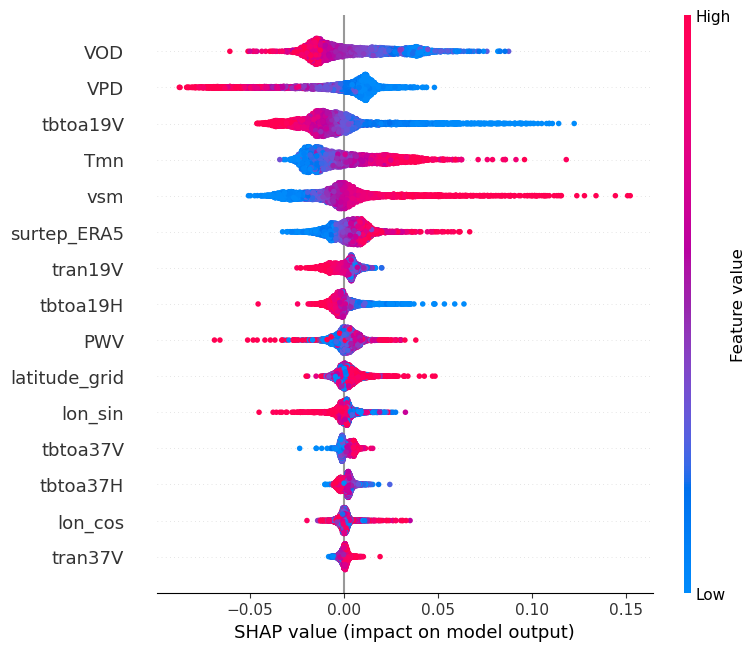

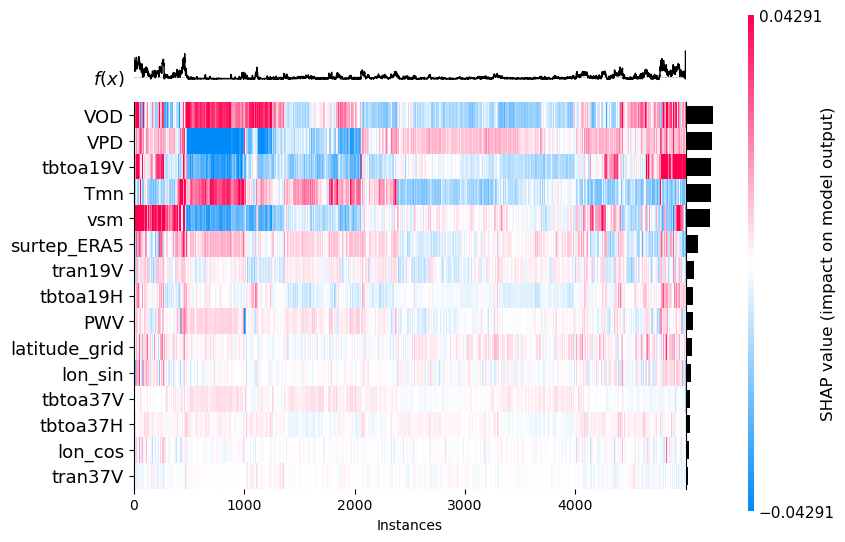

<Axes: xlabel='Instances'>

In [ ]:
# Global importance: bar chart (mean |SHAP|)
shap.plots.bar(shap_values, max_display=min(20, len(FINAL_FEATURE_SET)), show=True)

# Global distribution: beeswarm (per-sample SHAP by feature value)
shap.plots.beeswarm(shap_values, max_display=min(20, len(FINAL_FEATURE_SET)), show=True)

# Heatmap: samples sorted by model output, features sorted by importance
shap.plots.heatmap(shap_values, max_display=min(15, len(FINAL_FEATURE_SET)), show=True)

In [ ]:
# Dependence plots for the top-6 features by mean |SHAP|
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_ranking = (pd.Series(mean_abs_shap, index=list(FINAL_FEATURE_SET))
                  .sort_values(ascending=False))
top_features = shap_ranking.head(6).index.tolist()
print('Top-6 features by mean |SHAP|:', top_features)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.ravel(), top_features):
    shap.dependence_plot(feat, shap_values.values, X_explain_sample,
                         interaction_index='auto', ax=ax, show=False)
    ax.set_title(f'Dependence: {feat}')
plt.tight_layout()
plt.show()

# ── §7 SAVE ─────────────────────────────────────────────────────────────────────────────
feature_importance_absolute = pd.DataFrame({
    'feature': shap_ranking.index,
    'mean_abs_shap': shap_ranking.values,
}).reset_index(drop=True)
feature_importance_absolute.to_csv(f'{RESULTS_DIR}/feature_importance_absolute.csv', index=False)
print(f'Saved: {RESULTS_DIR}/feature_importance_absolute.csv  ({len(feature_importance_absolute)} features)')

In [ ]:
# SHAP interaction values on a smaller sub-sample (O(N*F^2) memory)
n_inter = min(1000, len(X_explain_sample))
X_inter = X_explain_sample.iloc[:n_inter]
shap_interaction = explainer_final.shap_interaction_values(X_inter)

inter_mean_abs = np.abs(shap_interaction).mean(axis=0)
# Zero out the diagonal (main effects) so we rank only cross-feature interactions
np.fill_diagonal(inter_mean_abs, 0.0)

feat_names = list(FINAL_FEATURE_SET)
inter_df = pd.DataFrame(inter_mean_abs, index=feat_names, columns=feat_names)
# Take upper triangle to avoid (a,b)/(b,a) duplicates
iu = np.triu_indices_from(inter_mean_abs, k=1)
top_pairs = (pd.Series(inter_mean_abs[iu],
                       index=pd.MultiIndex.from_arrays(
                           [[feat_names[i] for i in iu[0]],
                            [feat_names[j] for j in iu[1]]],
                           names=['feature_a', 'feature_b']))
             .sort_values(ascending=False)
             .head(15)
             .rename('mean_abs_interaction'))
display(top_pairs.to_frame())

,,mean_abs_interaction
feature_a,feature_b,
Tmn,VPD,0.009166
VOD,VPD,0.006742
vsm,VOD,0.003560
tbtoa19V,surtep_ERA5,0.003147
Tmn,PWV,0.002911
tbtoa19V,tbtoa19H,0.002443
PWV,VPD,0.002302
VOD,Tmn,0.002173
tbtoa19V,PWV,0.002093



--- best predicted | true=0.0000  pred=-0.0000  residual=-0.0000 ---


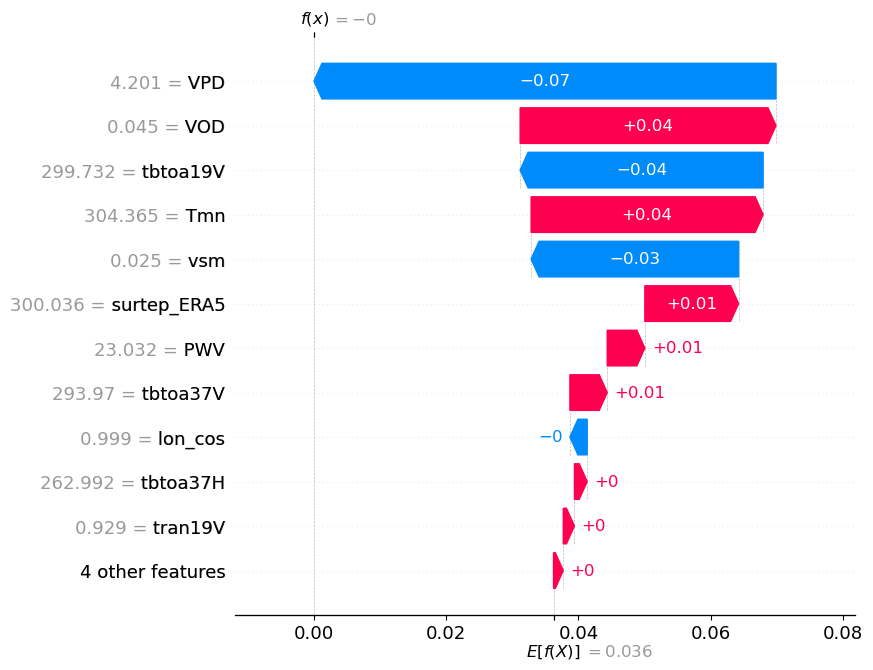


--- median error | true=0.1223  pred=0.1183  residual=-0.0040 ---


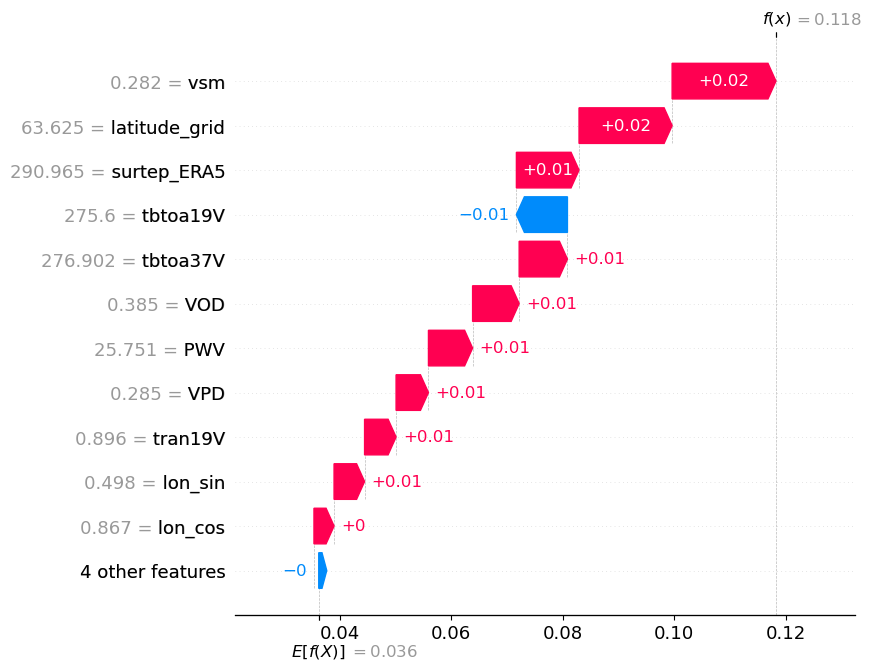


--- worst predicted | true=0.2038  pred=0.0827  residual=-0.1211 ---


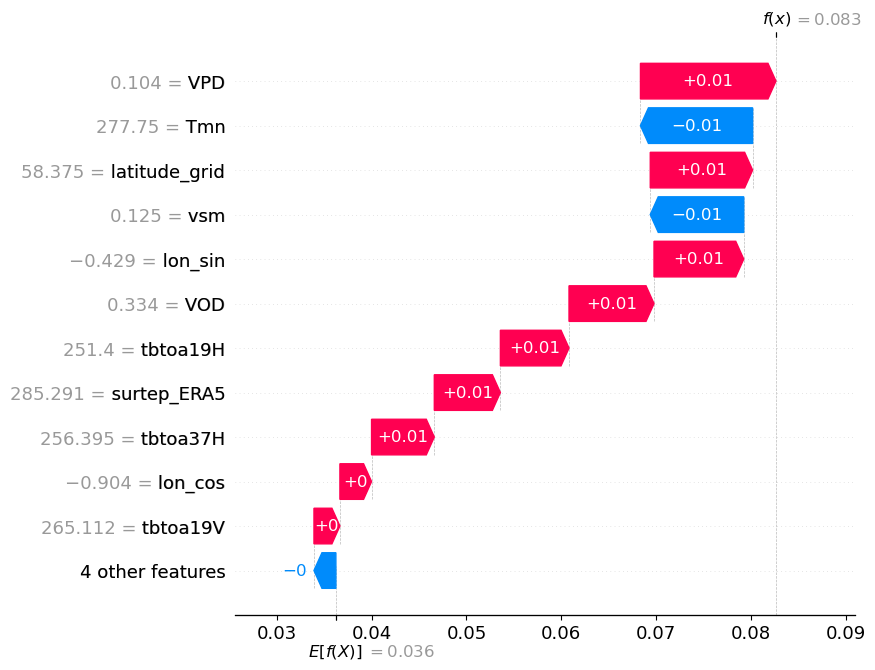

In [ ]:
# Local explanations for three representative test points:
# best predicted, median error, and worst predicted (by |residual|).
residuals_expl = y_explain_pred - y_explain_true.values
abs_resid = np.abs(residuals_expl)
order = np.argsort(abs_resid)
pick_local = {
    'best predicted': int(order[0]),
    'median error':   int(order[len(order) // 2]),
    'worst predicted': int(order[-1]),
}

for label, li in pick_local.items():
    print(f'\n--- {label} | true={y_explain_true.iloc[li]:.4f}  '
          f'pred={y_explain_pred[li]:.4f}  residual={residuals_expl[li]:+.4f} ---')
    shap.plots.waterfall(shap_values[li], max_display=12, show=True)

In [ ]:
# Segment analysis: mean |SHAP| by land-cover class and by fwns quantile.
seg_rows = []
feat_names = list(FINAL_FEATURE_SET)

# --- Per land-cover class (if `clase` is available in df_model) ---
if 'clase' in df_model.columns:
    seg_vals = df_model.loc[X_explain_sample.index, 'clase']
    for cls, idx_group in seg_vals.groupby(seg_vals).groups.items():
        positions = np.where(X_explain_sample.index.isin(idx_group))[0]
        if len(positions) < 20:
            continue
        mean_abs_seg = np.abs(shap_values.values[positions]).mean(axis=0)
        top_seg = pd.Series(mean_abs_seg, index=feat_names).nlargest(5)
        seg_rows.append({
            'segment': f'land_cover={cls}',
            'n': int(len(positions)),
            **{f'top{i+1}': f'{f} ({v:.4f})' for i, (f, v) in enumerate(top_seg.items())},
        })

# --- Per fwns quantile bin ---
# Determine actual number of bins after dropping duplicate edges, then match labels
_all_qlabels = ['Q1_low', 'Q2', 'Q3', 'Q4_high']
_, _qbin_edges = pd.qcut(y_explain_true.values, q=4, retbins=True, duplicates='drop')
_n_actual_bins = len(_qbin_edges) - 1
qbins = pd.qcut(y_explain_true.values, q=4,
                labels=_all_qlabels[:_n_actual_bins], duplicates='drop')
for qname in qbins.cat.categories:
    positions = np.where(qbins == qname)[0]
    if len(positions) < 20:
        continue
    mean_abs_q = np.abs(shap_values.values[positions]).mean(axis=0)
    top_q = pd.Series(mean_abs_q, index=feat_names).nlargest(5)
    seg_rows.append({
        'segment': f'fwns_{qname}',
        'n': int(len(positions)),
        **{f'top{i+1}': f'{f} ({v:.4f})' for i, (f, v) in enumerate(top_q.items())},
    })

segment_df = pd.DataFrame(seg_rows)
display(segment_df)


### Explainability Discussion

Global, local, and segment-level SHAP analyses together establish **which features
drive predictions across the distribution**, **how each feature's effect changes
with its value**, **which feature pairs interact most strongly**, and **whether the
drivers differ by land-cover class or `fwns` quantile**. Combined with the error
analysis in Chapter 8, this forms the operational basis for trusting the model's
predictions and flagging regimes where caution is warranted.


## 8. Error Analysis


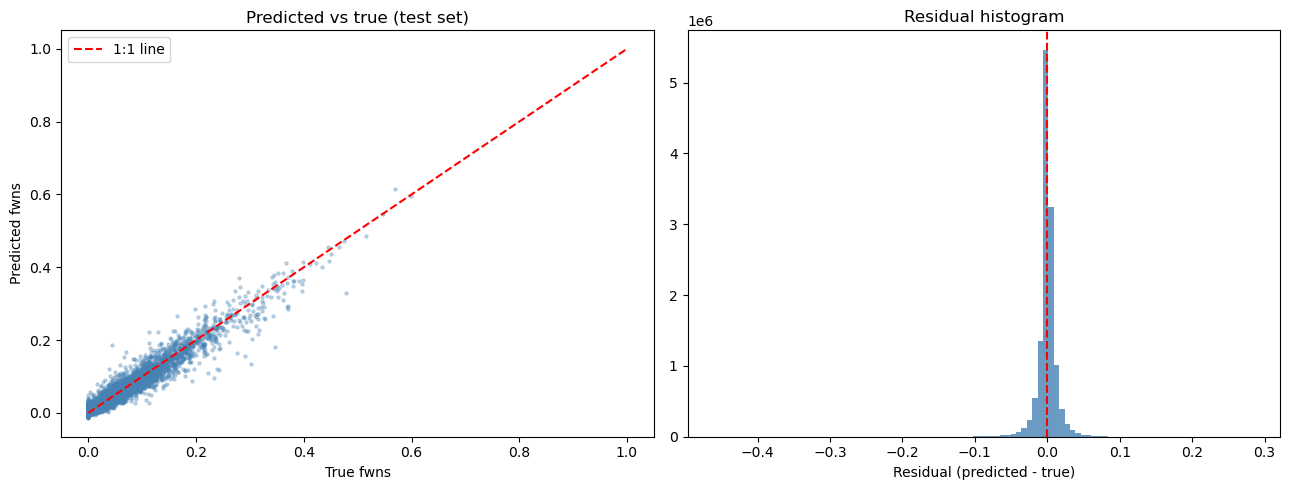

In [18]:
# Predictions on canonical test set for error analysis
X_err_test = df_model.loc[test_idx, FINAL_FEATURE_SET]
y_err_true = y.loc[test_idx]
y_err_pred = final_model.predict(X_err_test)
residuals = y_err_pred - y_err_true.values

# Scatter predicted vs true with 2D density colouring
# Diagonal concentration = good predictions; vertical spread = high variance regime
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample_n = min(10000, len(y_err_true))
idx_s = np.random.choice(len(y_err_true), size=sample_n, replace=False)

axes[0].scatter(y_err_true.values[idx_s], y_err_pred[idx_s],
                alpha=0.3, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='1:1 line')
axes[0].set_xlabel('True fwns')
axes[0].set_ylabel('Predicted fwns')
axes[0].set_title('Predicted vs true (test set)')
axes[0].legend()

# Residual histogram: look for symmetry and fat tails
axes[1].hist(residuals, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (predicted - true)')
axes[1].set_title('Residual histogram')
plt.tight_layout()
plt.show()

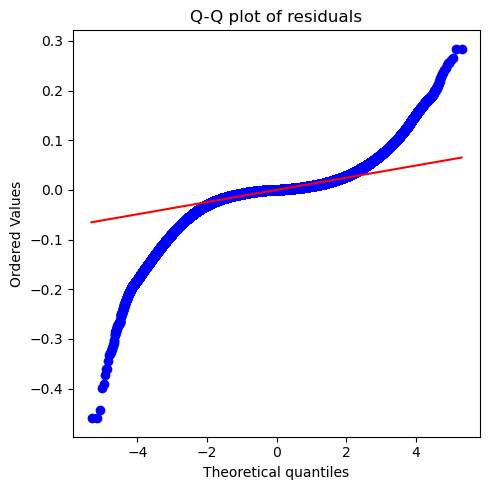

In [ ]:
# Q-Q plot: if residuals are Gaussian the points fall on the diagonal;
# curved tails indicate heavy-tailed or skewed errors
fig, ax = plt.subplots(figsize=(5, 5))
probplot(residuals, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals')
plt.tight_layout()
plt.show()

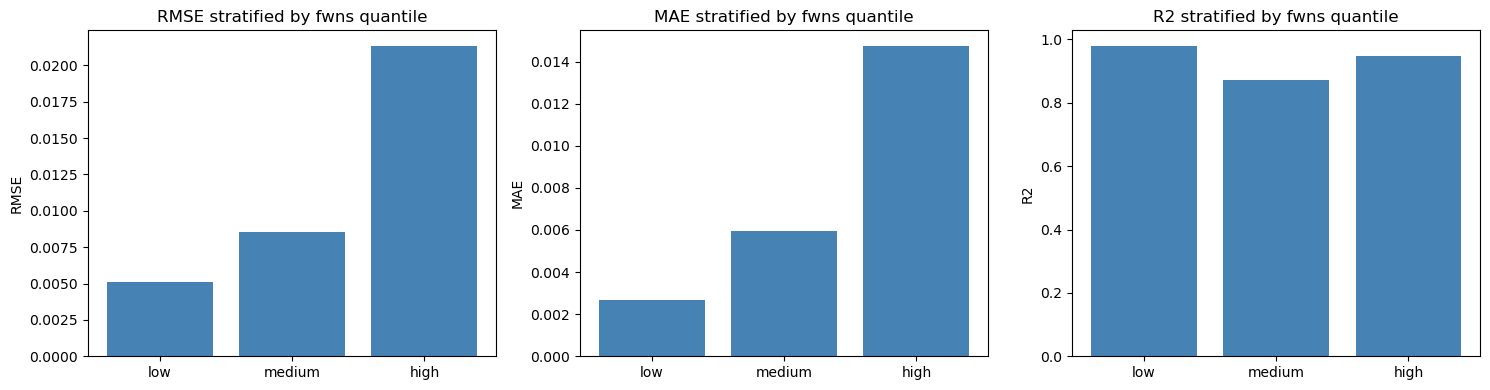

In [26]:
# Stratified metrics by fwns quantile
# High errors in specific strata point to regime-dependent model weaknesses
err_df = pd.DataFrame({
    'true': y_err_true.values,
    'pred': y_err_pred,
    'residuals': residuals,
    'abs_error': np.abs(residuals),
}, index=test_idx)

err_df['fwns_bin'] = pd.qcut(err_df['true'], q=3, labels=['low', 'medium', 'high'])

# Calculate metrics by fwns quantile
metrics = {}
for name in ['RMSE', 'MAE', 'R2']:
    metrics[name] = []

# Global mean for R2 calculation
global_mean = err_df['true'].mean()

for fwns_group in ['low', 'medium', 'high']:
    mask = err_df['fwns_bin'] == fwns_group
    group_true = err_df.loc[mask, 'true']
    group_residuals = err_df.loc[mask, 'residuals']

    rmse = np.sqrt(np.mean(group_residuals**2))
    mae = np.mean(np.abs(group_residuals))
    ss_res = np.sum(group_residuals**2)
    ss_tot = np.sum((group_true - global_mean)**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

    metrics['RMSE'].append(rmse)
    metrics['MAE'].append(mae)
    metrics['R2'].append(r2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fwns_labels = ['low', 'medium', 'high']
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    ax.bar(fwns_labels, metrics[metric], color='steelblue')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} stratified by fwns quantile')
plt.tight_layout()
plt.show()

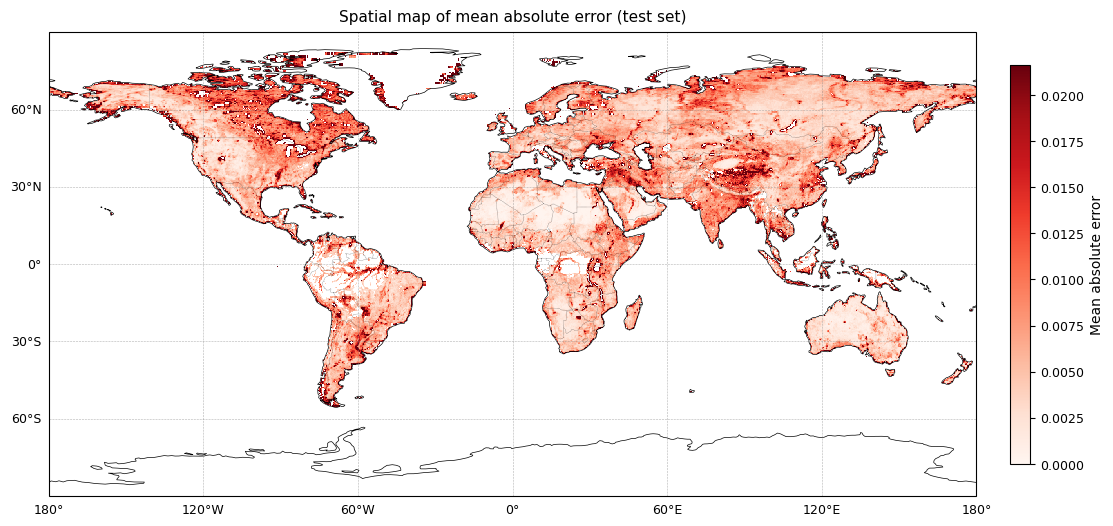

In [ ]:
# Spatial map of mean absolute error per grid cell
err_df['lat'] = df_raw.loc[test_idx, 'latitude_grid'].values
err_df['lon'] = df_raw.loc[test_idx, 'longitude_grid'].values
spatial_mae = err_df.groupby(['lat', 'lon'])['abs_error'].mean().reset_index()

# Remap longitudes [0, 360] to [-180, 180]
spatial_mae['lon'] = ((spatial_mae['lon'] + 180) % 360) - 180

pivot_mae = spatial_mae.pivot(index='lat', columns='lon', values='abs_error')
lats = pivot_mae.index.values
lons = pivot_mae.columns.values
data = pivot_mae.values

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

vmax = spatial_mae['abs_error'].quantile(0.95)
mesh = ax.pcolormesh(
    lons, lats, data,
    transform=ccrs.PlateCarree(),
    cmap='Reds', shading='auto',
    vmin=0, vmax=vmax,
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(60)
gl.ylocator = mticker.MultipleLocator(30)
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

ax.set_global()

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.7, pad=0.03)
cbar.set_label('Mean absolute error', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title('Spatial map of mean absolute error (test set)', fontsize=11, pad=8)
plt.tight_layout()
plt.show()


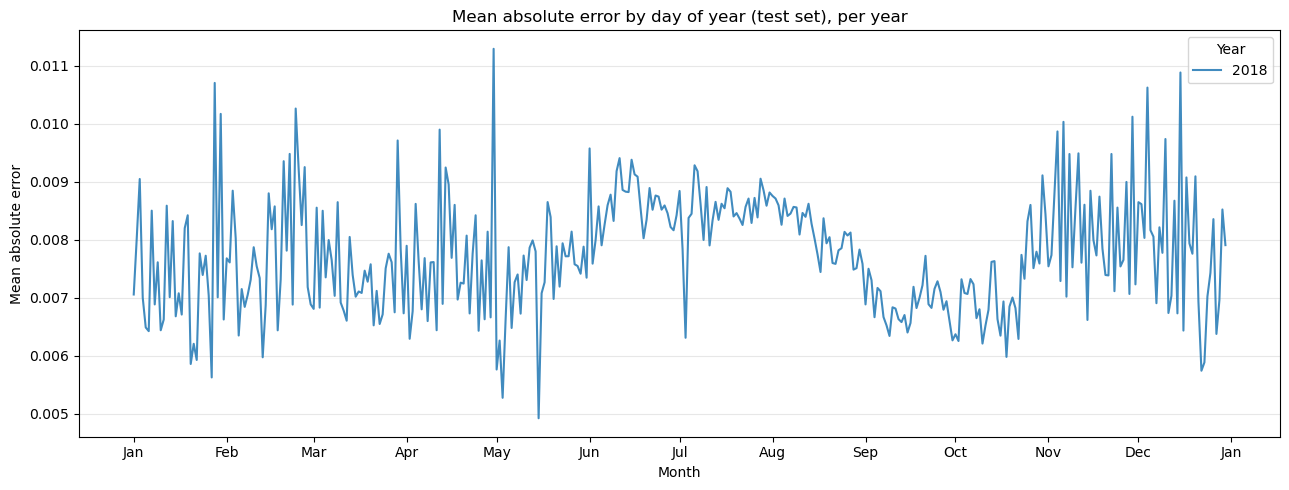

In [ ]:
# Temporal plot: mean absolute error by day of year, coloured by year
err_df['day_of_year'] = df_raw.loc[test_idx, 'day_of_year'].values
err_df['year']        = df_raw.loc[test_idx, 'year'].values

temporal_mae = (
    err_df.groupby(['year', 'day_of_year'])['abs_error']
    .mean()
    .reset_index()
)

years_in_test = sorted(temporal_mae['year'].unique().astype(int))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(years_in_test)))

fig, ax = plt.subplots(figsize=(13, 5))
for year, color in zip(years_in_test, colors):
    subset = temporal_mae[temporal_mae['year'] == year].sort_values('day_of_year')
    dates = pd.to_datetime(
        subset['day_of_year'].astype(int).apply(lambda d: f'2000-{d:03d}'),
        format='%Y-%j',
    )
    ax.plot(dates, subset['abs_error'], label=str(year),
            color=color, alpha=0.85, linewidth=1.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlabel('Month')
ax.set_ylabel('Mean absolute error')
ax.set_title('Mean absolute error by day of year (test set), per year')
ax.legend(title='Year', ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ── §8 SAVE ─────────────────────────────────────────────────────────────────────────────
_overall = {
    'split': 'overall',
    'RMSE': float(np.sqrt(np.mean((y_err_pred - y_err_true.values)**2))),
    'MAE':  float(np.mean(np.abs(y_err_pred - y_err_true.values))),
    'R2':   float(r2_score(y_err_true, y_err_pred)),
}
_strata = [
    {'split': f'fwns_{label}', 'RMSE': metrics['RMSE'][i],
     'MAE': metrics['MAE'][i], 'R2': metrics['R2'][i]}
    for i, label in enumerate(['low', 'medium', 'high'])
]
final_metrics = pd.DataFrame([_overall] + _strata)
final_metrics.to_csv(f'{RESULTS_DIR}/final_metrics.csv', index=False)
print(f'Saved: {RESULTS_DIR}/final_metrics.csv')
print(final_metrics.round(6).to_string(index=False))

## 9. Final Model Summary


In [ ]:
# Retrain on the full dataset (train + test combined) using exhaustive HPO params
X_full = df_model[FINAL_FEATURE_SET]
y_full = y

final_model_fulldata = XGBRegressor(**{k: v for k, v in full_HPO_params.items()
                                       if k not in ('objective', 'eval_metric', 'tree_method')})
final_model_fulldata.fit(X_full, y_full)
print('Retrained final model on full dataset.')
print(f'Full dataset size: {len(X_full):,} rows, {len(FINAL_FEATURE_SET)} features')

In [ ]:
# Build structured index splits for slice-level bias checks.
# final_model_fulldata was trained on all data, so these are in-sample slice evaluations
# that reveal systematic under/over-fitting by time period or geographic region.
_all_idx = df_model.index

# Temporal: last available year as the held-out slice
_year_vals = df_raw.loc[_all_idx, 'year']
_last_yr   = int(_year_vals.max())
train_idx_time = _all_idx[(_year_vals < _last_yr).values]
test_idx_time  = _all_idx[(_year_vals == _last_yr).values]

# Geographic corner: extreme latitudes (bottom/top 20%) as the held-out slice
_lat_vals = df_raw.loc[_all_idx, 'latitude_grid']
_q20, _q80 = _lat_vals.quantile(0.20), _lat_vals.quantile(0.80)
train_idx_corner = _all_idx[((_lat_vals >= _q20) & (_lat_vals <= _q80)).values]
test_idx_corner  = _all_idx[((_lat_vals <  _q20) | (_lat_vals >  _q80)).values]

# Geographic block: eastern vs western hemisphere
_lon_vals = df_raw.loc[_all_idx, 'longitude_grid']
_lon_norm = ((_lon_vals + 180) % 360) - 180   # remap [0, 360] -> [-180, 180]
train_idx_block = _all_idx[(_lon_norm <= 0).values]
test_idx_block  = _all_idx[(_lon_norm >  0).values]

# Evaluate final model on each slice
gen_rows = []
for split_name, tr_idx_s, te_idx_s in [
    ('temporal',          train_idx_time,   test_idx_time),
    ('geographic_corner', train_idx_corner, test_idx_corner),
    ('geographic_block',  train_idx_block,  test_idx_block),
]:
    X_te_s = df_model.loc[te_idx_s, FINAL_FEATURE_SET]
    y_te_s = y.loc[te_idx_s]
    y_pred_s = final_model_fulldata.predict(X_te_s)
    gen_rows.append({
        'split': split_name,
        'MAE':  mean_absolute_error(y_te_s, y_pred_s),
        'RMSE': root_mean_squared_error(y_te_s, y_pred_s),
        'R2':   r2_score(y_te_s, y_pred_s),
    })

display(pd.DataFrame(gen_rows).round(6))

In [ ]:
# Consolidated comparison table across all three model tiers
# Look for monotonic improvement from physics baseline → forward-study best → optimized

final_r2_test = r2_score(
    y.loc[test_idx],
    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET])
)
final_mae_test = mean_absolute_error(
    y.loc[test_idx],
    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET])
)
final_rmse_test = root_mean_squared_error(
    y.loc[test_idx],
    final_model.predict(df_model.loc[test_idx, FINAL_FEATURE_SET])
)

summary_table = pd.DataFrame([
    {
        'model_tier': 'Physics baseline (DR)',
        'RMSE': physics_baseline_metrics['RMSE'],
        'MAE':  physics_baseline_metrics['MAE'],
        'R2':   physics_baseline_metrics['R2'],
    },
    {
        'model_tier': 'XGBoost (forward-study best)',
        'RMSE': ref_row['RMSE'],
        'MAE':  ref_row['MAE'],
        'R2':   ref_row['R2'],
    },
    {
        'model_tier': 'XGBoost (mediumweight)',
        'RMSE': root_mean_squared_error(y.loc[test_idx],
                         mediumweight_model.predict(X_selected_test)),
        'MAE':  mean_absolute_error(y.loc[test_idx],
                         mediumweight_model.predict(X_selected_test)),
        'R2':   r2_score(y.loc[test_idx],
                         mediumweight_model.predict(X_selected_test)),
    },
    {
        'model_tier': 'XGBoost (final, full data)',
        'RMSE': final_rmse_test,
        'MAE':  final_mae_test,
        'R2':   final_r2_test,
    },
])
display(summary_table.round(6))

In [ ]:
# Save final model booster to disk
final_model_fulldata.get_booster().save_model(f'{MODEL_DIR}/final_model_fulldata.json')
print('Saved: final_model_fulldata.json')

Saved: final_model_fulldata.json


In [ ]:
# Pipeline summary — final cell
r2 = final_r2_test
print(
    f'Pipeline complete. Final feature set: {len(FINAL_FEATURE_SET)} features. '
    f'Final test R\u00b2: {r2:.4f}. Model saved to final_model_fulldata.json.'
)

Pipeline complete. Final feature set: 15 features. Final test R²: 0.9476. Model saved to final_model_fulldata.json.
